In [1]:
import sys
import subprocess
import pkgutil

def ensure_package(pkg_name, pip_name=None):
    if pkgutil.find_loader(pkg_name) is None:
        name = pip_name or pkg_name
        print(f"Installing {name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", name])
    else:
        print(f"{pkg_name} already installed.")

ensure_package("torch_geometric", "torch-geometric")


torch_geometric already installed.


In [97]:
from pathlib import Path

use_day_embedding = True
day_emb_dim       = 3

CONFIG = {
    "BASE_DIR"          : Path("."),
    "PATH_NETWORK"      : Path("Gas Network Data.xlsx"),
    "PATH_CONS_DISTRIB" : Path("./input/Gas Cons Distrib.xlsx"),
    "PATH_CONS_EXPORT"  : Path("./input/Gas Cons Export.xlsx"),
    "PATH_CONS_IND"     : Path("./input/Gas Cons Ind.xlsx"),
    "PATH_DECISION"     : Path("./output/Decision_variablesRU.xlsx"),

    "MONTHS"   : [f"{m:02d}" for m in range(1, 13)],
    "NUM_NODES": 28,
    "WELL_IDX" : [0, 4, 16, 17],
    "TARGET_COLS_ARE_ALL_G": True,

    "HIST_HOURS"    : 72,
    "HORIZON_HOURS" : 24,
    "STRIDE_HOURS"  : 24,

    "TRAIN_END": "2024-10-01 00:00:00",
    "VAL_END"  : "2024-11-01 00:00:00",

    "USE_PR_HISTORY"                 : False,
    "USE_RES_DEMAND_HISTORY"         : True,
    "USE_IND_DEMAND_HISTORY"         : True,
    "USE_EXP_DEMAND_HISTORY"         : False,
    "USE_GFPP_GAS_LOAD_HISTORY"      : True,
    "USE_G_HISTORY"                  : False,
    "USE_RAW_P_HISTORY_ON_GAS_NODES" : False,

    "USE_NODE_STATIC_IS_WELL"           : True,
    "USE_NODE_STATIC_SHARES"            : True,
    "USE_NODE_STATIC_PRESSURE_BOUNDS"   : True,
    "USE_NODE_STATIC_DEGREE"            : True,
    "USE_NODE_STATIC_IS_GFPP_LOAD_NODE" : True,
    "USE_NODE_STATIC_GFPP_COUNT"        : True,

    "EDGE_STATIC_COLUMNS": [
        "Natural gas flow constant [MNm3/(bar*h)2]",
        "Compressor factor",
        "High Linepack",
        "Initial linepack [MNm3]",
        "Linepack constant [MNm3/bar]",
        "Estimated lenght [km]",
    ],
    "USE_BIDIRECTIONAL_EDGES": True,

    "GFPP_P_TO_MW_MULTIPLIER"             : 100.0,
    "GFPP_GAS_ENERGY_CONTENT_MWH_PER_MNM3": 11000.0,
    "GFPP_DEFAULT_EFFICIENCY"             : 0.55,
    "GFPP_EFFICIENCY_BY_GENERATOR"        : {},
    "GFPP_USE_OPTIONAL_EFFICIENCY_COLUMN" : False,
    "GFPP_OPTIONAL_EFFICIENCY_COLUMN_NAME": "Efficiency",

    "MODEL_TYPE"          : "gine",
    "HIDDEN_DIM"          : 8,
    "ENCODER_HIDDEN_DIMS" : [16, 8],
    "DECODER_HIDDEN_DIMS" : [8, 16],
    "NUM_MP_LAYERS"       : 2,
    "DROPOUT"             : 0.1,
    "USE_BATCHNORM"       : True,
    "RESIDUAL"            : False,

    "SEED"                    : 42,
    "DEVICE"                  : "cpu",
    "EPOCHS"                  : 300,
    "BATCH_SIZE"              : 24,
    "LR"                      : 5e-4,
    "WEIGHT_DECAY"            : 1e-4,
    "GRAD_CLIP_NORM"          : 2.0,
    "EARLY_STOPPING_PATIENCE" : 30,
    "EARLY_STOPPING_MIN_DELTA": 0.0,
    "SCHEDULER_FACTOR"        : 0.6,
    "SCHEDULER_PATIENCE"      : 4,
    "SCHEDULER_MIN_LR"        : 1e-5,

    "NUM_ALIGNMENT_CHECKS" : 10,
    "NUM_PLOT_SAMPLES"     : 3,
    "PLOT_WELL_LOCAL_INDEX": 0,
    "SAVE_MODEL_STATE"     : False,
    "MODEL_STATE_PATH"     : Path("spatial_gas_gnn_gfpp.pt"),
}

PATHS = {
    "network"      : CONFIG["BASE_DIR"] / CONFIG["PATH_NETWORK"],
    "cons_distrib" : CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_DISTRIB"],
    "cons_export"  : CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_EXPORT"],
    "cons_ind"     : CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_IND"],
    "decision"     : CONFIG["BASE_DIR"] / CONFIG["PATH_DECISION"],
}

HIST    = CONFIG["HIST_HOURS"]
HOR     = CONFIG["HORIZON_HOURS"]
STR     = CONFIG["STRIDE_HOURS"]
N_WELLS = len(CONFIG["WELL_IDX"])

print("Fichiers attendus :")
for k, v in PATHS.items():
    print(f"  {k}: {v.resolve()} | exists={v.exists()}")
for p in PATHS.values():
    assert p.exists(), f"Fichier introuvable: {p}"
print(f"\nCONFIG OK.  use_day_embedding={use_day_embedding}  day_emb_dim={day_emb_dim}")


Fichiers attendus :
  network: C:\Users\yoans\TFE - GAZ\Gas Network Data.xlsx | exists=True
  cons_distrib: C:\Users\yoans\TFE - GAZ\input\Gas Cons Distrib.xlsx | exists=True
  cons_export: C:\Users\yoans\TFE - GAZ\input\Gas Cons Export.xlsx | exists=True
  cons_ind: C:\Users\yoans\TFE - GAZ\input\Gas Cons Ind.xlsx | exists=True
  decision: C:\Users\yoans\TFE - GAZ\output\Decision_variablesRU.xlsx | exists=True

CONFIG OK.  use_day_embedding=True  day_emb_dim=3


In [60]:
import copy
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, NNConv

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["SEED"])

DEVICE = torch.device(
    "cuda" if (CONFIG["DEVICE"] == "cuda" and torch.cuda.is_available()) else "cpu"
)
print("DEVICE =", DEVICE)

def pretty_shape(name, x):
    if isinstance(x, (np.ndarray, torch.Tensor, pd.DataFrame, pd.Series)):
        print(f"{name}: shape={getattr(x, 'shape', None)}")
    else:
        print(f"{name}: type={type(x)}")

def drop_unnamed_first_col(df):
    if len(df.columns) > 0 and str(df.columns[0]).startswith("Unnamed"):
        return df.drop(columns=[df.columns[0]])
    return df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


DEVICE = cpu


In [61]:
def show_excel_overview(path, n_preview_rows=3):
    xls = pd.ExcelFile(path)
    print("=" * 100)
    print(path.name)
    print("Sheets:", xls.sheet_names)
    for sheet in xls.sheet_names[:8]:
        df = pd.read_excel(path, sheet_name=sheet, nrows=n_preview_rows)
        print(f"\n[{sheet}] preview shape = {df.shape}")
        display(df.head(n_preview_rows))

for p in PATHS.values():
    show_excel_overview(p)


Gas Network Data.xlsx
Sheets: ['Nodes', 'Pipelines', 'Check', 'Well', 'GasWellMap', 'GFPPMap', 'KI', 'KO']

[Nodes] preview shape = (3, 6)


,Gas Node,Res_Load_share_%,Ind_Load_share_%,Exp_Load_share_%,Pr_min [bar],Pr_max [bar]
0,1,0.000000,0.000000,0,60,80
1,2,0.055556,0.105263,0,60,80
2,3,0.055556,0.052632,0,60,80



[Pipelines] preview shape = (3, 10)


,Pipeline,From node,To node,Natural gas flow constant [MNm3/(bar*h)2],Compressor factor,High Linepack,Initial linepack [MNm3],Linepack constant [MNm3/bar],Estimated lenght [km],Linepack constant quantifies
0,1,1,2,0.14400,1,1,12.144166,0.1680,25,how much gas volume is
1,2,2,3,0.00739,1,1,10.592369,0.1470,30,added or removed from the
2,3,2,4,0.08270,1,1,2.515726,0.0349,35,pipeline for each change in pressure



[Check] preview shape = (3, 8)


...

,Unnamed: 0,0
0,0,7370.565156
1,0,11222.879449
2,0,11342.246438



[q-02-2024] preview shape = (3, 34)


,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32
0,0,2.135997,0.079173,0.888889,1.120665,0.000000,1.398563,0.444444,0.668141,0.920204,0.668141,0.407476,0.274094,0.162472,0.063663,1.119373,1.794794,0.095079,1.706983,0.070286,1.526005,1.854820,1.854820,0.581626,0.650085,0.081186,0.511128,1.426165,0.039381,0.316843,1.140996,0.122243,0.242913,0.069600
1,1,2.142751,0.136875,0.025496,1.777778,0.003787,1.238461,0.444444,1.353063,0.866072,1.353063,0.412368,0.205017,0.095619,0.030115,1.253699,2.252982,0.008942,2.222222,0.083015,1.428634,1.634820,1.634820,0.461759,1.052778,0.110504,0.802475,1.443289,0.039128,0.508049,1.173227,0.123710,0.242771,0.074839
2,2,2.222222,0.136602,0.541976,1.333333,0.000000,1.289222,0.471824,0.872719,0.921929,0.872719,0.427337,0.238019,0.126809,0.037653,1.191427,2.402801,0.222111,2.002352,0.054569,1.277661,1.414939,1.414939,0.311759,0.521813,0.062763,0.444444,1.451126,0.031659,0.268004,1.292509,0.124382,0.245069,0.076465



[pr-02-2024] preview shape = (3, 29)


,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,71.729656,71.508821,71.475857,71.442677,71.409920,71.399560,71.471281,71.327591,70.919856,67.958230,67.389111,66.876260,66.173874,71.520934,68.053221,61.975440,62.222222,68.977985,68.888889,73.333333,68.389042,70.733054,72.635072,66.666667,71.461110,71.468456,71.475857,71.440224
1,1,71.933808,71.711674,71.654684,71.710725,71.457459,71.447099,71.816831,71.383502,70.972564,68.888889,68.553949,68.311353,67.467833,71.658772,69.324064,62.029008,62.222222,67.232759,67.179398,75.555556,66.666667,72.100501,73.959449,67.969750,71.639702,71.647137,71.654532,71.616217
2,2,72.165572,71.928155,71.871279,71.900733,71.791606,71.779332,71.945073,71.707042,71.285605,68.817480,68.373282,68.069957,67.299356,71.976582,68.888889,62.077677,62.222222,68.368688,68.335174,73.333333,67.816545,71.332126,72.851812,67.894834,71.856338,71.863813,71.871279,71.832131


In [62]:
nodes_df      = pd.read_excel(PATHS["network"], sheet_name="Nodes")
pipes_df      = pd.read_excel(PATHS["network"], sheet_name="Pipelines")
well_df       = pd.read_excel(PATHS["network"], sheet_name="Well")
gaswell_map_df= pd.read_excel(PATHS["network"], sheet_name="GasWellMap")
gfpp_map_df   = pd.read_excel(PATHS["network"], sheet_name="GFPPMap")
ki_df         = pd.read_excel(PATHS["network"], sheet_name="KI")
ko_df         = pd.read_excel(PATHS["network"], sheet_name="KO")

num_nodes = CONFIG["NUM_NODES"]
well_idx  = CONFIG["WELL_IDX"]

for name, df in [("nodes_df", nodes_df), ("pipes_df", pipes_df), ("well_df", well_df),
                 ("gaswell_map_df", gaswell_map_df), ("gfpp_map_df", gfpp_map_df),
                 ("ki_df", ki_df), ("ko_df", ko_df)]:
    pretty_shape(name, df)

assert len(nodes_df) == num_nodes
assert len(well_idx) == 4
assert pipes_df["From node"].min() >= 1 and pipes_df["To node"].min() >= 1
assert pipes_df["From node"].max() <= num_nodes and pipes_df["To node"].max() <= num_nodes

print("Colonnes Nodes    :", list(nodes_df.columns))
print("Colonnes Pipelines:", list(pipes_df.columns))
print("Colonnes GFPPMap  :", list(gfpp_map_df.columns))

display(nodes_df.head())
display(pipes_df.head())
display(well_df)


nodes_df: shape=(28, 6)
pipes_df: shape=(33, 10)
well_df: shape=(4, 10)
gaswell_map_df: shape=(28, 4)
gfpp_map_df: shape=(28, 24)
ki_df: shape=(9, 12)
ko_df: shape=(26, 12)
Colonnes Nodes    : ['Gas Node', 'Res_Load_share_%', 'Ind_Load_share_%', 'Exp_Load_share_%', 'Pr_min [bar]', 'Pr_max [bar]']
Colonnes Pipelines: ['Pipeline', 'From node', 'To node', 'Natural gas flow constant [MNm3/(bar*h)2]', 'Compressor factor', 'High Linepack', 'Initial linepack [MNm3]', 'Linepack constant [MNm3/bar]', 'Estimated lenght [km]', 'Linepack constant quantifies']
Colonnes GFPPMap  : ['Gen1', 'Gen2', 'Gen3', 'Gen4', 'Gen5', 'Gen6', 'Gen7', 'Gen8', 'Gen9', 'Gen10', 'Gen11', 'Gen12', 'Gen13', 'Gen14', 'Gen15', 'Gen16', 'Gen17', 'Gen18', 'Gen19', 'Gen20', 'Gen21', 'Gen22', 'Gen23', 'Gen24']


,Gas Node,Res_Load_share_%,Ind_Load_share_%,Exp_Load_share_%,Pr_min [bar],Pr_max [bar]
0,1,0.000000,0.000000,0.0,60,80
1,2,0.055556,0.105263,0.0,60,80
2,3,0.055556,0.052632,0.0,60,80
3,4,0.055556,0.052632,0.0,60,80
4,5,0.000000,0.000000,0.0,60,80


,Pipeline,From node,To node,Natural gas flow constant [MNm3/(bar*h)2],Compressor factor,High Linepack,Initial linepack [MNm3],Linepack constant [MNm3/bar],Estimated lenght [km],Linepack constant quantifies
0,1,1,2,0.14400,1.0,1,12.144166,0.1680,25.0,how much gas volume is
1,2,2,3,0.00739,1.0,1,10.592369,0.1470,30.0,added or removed from the
2,3,2,4,0.08270,1.0,1,2.515726,0.0349,35.0,pipeline for each change in pressure
3,4,2,6,0.08270,1.0,1,2.516711,0.0349,30.0,NaN
4,5,3,27,0.07670,1.0,0,0.000000,0.0142,65.0,NaN


,Gas node,Gmax [MNm3/h],Day-ahead offer price [€/MNm3],Spot Market TTF Q4 2024 :,Unnamed: 4,Unnamed: 5,GCV moyen décembre :,Unnamed: 7,Unnamed: 8,OLD Day-ahead offer price (€/Mm3)
0,1,4.0,497394,43.251667,€/MWh,NaN,11.5,kWh/Nm3,NaN,65717.14
1,5,2.5,497394,0.043252,€/kWh,NaN,NaN,NaN,NaN,78860.57
2,17,2.2,497394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18,1.5,497394,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
def read_simple_monthly_series(path, months, value_col):
    parts = []
    for m in months:
        df = pd.read_excel(path, sheet_name=f"{m}-2024")
        df = df[["Date Time", value_col]].copy()
        df["Date Time"] = pd.to_datetime(df["Date Time"])
        df = df.rename(columns={value_col: "value"})
        df["month"] = m
        parts.append(df)
    return pd.concat(parts, ignore_index=True).sort_values("Date Time").reset_index(drop=True)

def read_decision_tensor(prefix, months, decision_path):
    all_values, all_times = [], []
    for m in months:
        df = pd.read_excel(decision_path, sheet_name=f"{prefix}-{m}-2024")
        df = drop_unnamed_first_col(df)
        arr = df.to_numpy(dtype=float)
        idx = pd.date_range(start=pd.Timestamp(f"2024-{m}-01"), periods=len(df), freq="h")
        all_values.append(arr)
        all_times.append(idx)
    values = np.vstack(all_values)
    times  = pd.DatetimeIndex(np.concatenate([x.to_numpy() for x in all_times]))
    return values, times


In [64]:
MONTHS = CONFIG["MONTHS"]

cons_distrib_df = read_simple_monthly_series(PATHS["cons_distrib"], MONTHS, "Physical Flow (MNm3)")
cons_ind_df     = read_simple_monthly_series(PATHS["cons_ind"],     MONTHS, "Physical Flow (MNm3)")
cons_export_df  = read_simple_monthly_series(PATHS["cons_export"],  MONTHS, "Physical Flow (MNm3)")

g_full,  ts_g  = read_decision_tensor("g",  MONTHS, PATHS["decision"])
pr_full, ts_pr = read_decision_tensor("pr", MONTHS, PATHS["decision"])
q_full,  ts_q  = read_decision_tensor("q",  MONTHS, PATHS["decision"])
p_full,  ts_p  = read_decision_tensor("p",  MONTHS, PATHS["decision"])

assert len(cons_distrib_df) == len(cons_ind_df) == len(cons_export_df)
assert len(ts_g) == len(ts_pr) == len(ts_q) == len(ts_p) == len(cons_distrib_df)
assert (ts_g == ts_pr).all() and (ts_g == ts_q).all() and (ts_g == ts_p).all()
assert (ts_g == pd.DatetimeIndex(cons_distrib_df["Date Time"])).all()
assert (ts_g == pd.DatetimeIndex(cons_ind_df["Date Time"])).all()
assert (ts_g == pd.DatetimeIndex(cons_export_df["Date Time"])).all()

assert g_full.shape[1] == 4
assert pr_full.shape[1] == CONFIG["NUM_NODES"]
assert p_full.shape[1]  == gfpp_map_df.shape[1]

print("Plage temporelle :", ts_g.min(), "->", ts_g.max())
print("Nombre total d'heures :", len(ts_g))

for name, arr in [("g_full", g_full), ("pr_full", pr_full), ("p_full", p_full)]:
    pretty_shape(name, arr)


Plage temporelle : 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
Nombre total d'heures : 8784
g_full: shape=(8784, 4)
pr_full: shape=(8784, 28)
p_full: shape=(8784, 24)


In [65]:
gfpp_map    = gfpp_map_df.to_numpy(dtype=float)
gen_cols    = list(gfpp_map_df.columns)
num_generators = len(gen_cols)

assert gfpp_map.shape == (num_nodes, num_generators)

generator_to_gas_node = {}
generators_without_gas_node = []
generators_with_multiple_nodes = []

for g_idx, gen_name in enumerate(gen_cols):
    connected_rows = np.where(gfpp_map[:, g_idx] > 0.5)[0]
    if len(connected_rows) == 0:
        generators_without_gas_node.append(g_idx)
    elif len(connected_rows) == 1:
        generator_to_gas_node[g_idx] = int(connected_rows[0])
    else:
        generators_with_multiple_nodes.append((g_idx, connected_rows.tolist()))

assert len(generators_with_multiple_nodes) == 0

connected_generator_idx = sorted(generator_to_gas_node.keys())
connected_gas_nodes     = sorted(set(generator_to_gas_node.values()))

print("Générateurs reliés au gaz :", len(connected_generator_idx))
print("Nœuds gas GFPP (0-based)  :", connected_gas_nodes)
print("Nœuds gas GFPP (1-based)  :", [n + 1 for n in connected_gas_nodes])

gfpp_count_per_node = np.zeros(num_nodes, dtype=int)
for g_idx, node_idx in generator_to_gas_node.items():
    gfpp_count_per_node[node_idx] += 1

gfpp_is_load_node = (gfpp_count_per_node > 0).astype(float)

display(pd.DataFrame({
    "generator_idx_0based" : connected_generator_idx,
    "generator_name"       : [gen_cols[g] for g in connected_generator_idx],
    "gas_node_idx_0based"  : [generator_to_gas_node[g] for g in connected_generator_idx],
    "gas_node_label_1based": [generator_to_gas_node[g] + 1 for g in connected_generator_idx],
}).sort_values(["gas_node_idx_0based", "generator_idx_0based"]).reset_index(drop=True))


Générateurs reliés au gaz : 22
Nœuds gas GFPP (0-based)  : [1, 2, 5, 7, 8, 10, 12, 18, 22, 23, 26]
Nœuds gas GFPP (1-based)  : [2, 3, 6, 8, 9, 11, 13, 19, 23, 24, 27]


,generator_idx_0based,generator_name,gas_node_idx_0based,gas_node_label_1based
0,3,Gen4,1,2
1,4,Gen5,1,2
2,6,Gen7,2,3
3,14,Gen15,5,6
4,15,Gen16,5,6
5,16,Gen17,5,6
6,17,Gen18,5,6
7,9,Gen10,7,8
8,10,Gen11,7,8
9,11,Gen12,7,8


In [66]:
eff_by_gen = np.full(num_generators, CONFIG["GFPP_DEFAULT_EFFICIENCY"], dtype=float)
for g_idx, eff_val in CONFIG["GFPP_EFFICIENCY_BY_GENERATOR"].items():
    eff_by_gen[g_idx] = float(eff_val)

base_multiplier    = float(CONFIG["GFPP_P_TO_MW_MULTIPLIER"])
gas_energy_content = float(CONFIG["GFPP_GAS_ENERGY_CONTENT_MWH_PER_MNM3"])

p_full_mw = p_full * base_multiplier

gfpp_gas_consumption_per_gen = np.zeros_like(p_full_mw, dtype=float)
for g_idx in connected_generator_idx:
    gfpp_gas_consumption_per_gen[:, g_idx] = (
        p_full_mw[:, g_idx] / (gas_energy_content * eff_by_gen[g_idx])
    )

gfpp_gas_nodal = np.zeros((len(ts_g), num_nodes), dtype=float)
for g_idx in connected_generator_idx:
    node_idx = generator_to_gas_node[g_idx]
    gfpp_gas_nodal[:, node_idx] += gfpp_gas_consumption_per_gen[:, g_idx]

for hour_idx in [0, 1, 2, 100, 1000, len(ts_g) - 1]:
    for node_idx in connected_gas_nodes[:min(6, len(connected_gas_nodes))]:
        gens_here = [g for g, n in generator_to_gas_node.items() if n == node_idx]
        assert np.isclose(
            gfpp_gas_nodal[hour_idx, node_idx],
            gfpp_gas_consumption_per_gen[hour_idx, gens_here].sum()
        )

pretty_shape("gfpp_gas_nodal", gfpp_gas_nodal)
print("Agrégation GFPP OK.")
print(f"  min={gfpp_gas_nodal.min():.6f}  max={gfpp_gas_nodal.max():.6f}  mean={gfpp_gas_nodal.mean():.6f}")


gfpp_gas_nodal: shape=(8784, 28)
Agrégation GFPP OK.
  min=0.000000  max=0.205289  mean=0.013867


In [67]:
print("=== DIAGNOSTIC GFPP ===")
print("Générateurs reliés au gaz :", len(connected_generator_idx))
print("Indices p (0-based)        :", connected_generator_idx)
print("Gas nodes impactés (0-based):", connected_gas_nodes)
print("Shape gfpp_gas_nodal        :", gfpp_gas_nodal.shape)

rows = []
for hour_idx in [0, 1, 2, 24, 48, 72]:
    for node_idx in connected_gas_nodes[:min(8, len(connected_gas_nodes))]:
        gens_here = [g for g, n in generator_to_gas_node.items() if n == node_idx]
        row = {
            "hour_idx"             : hour_idx,
            "timestamp"            : ts_g[hour_idx],
            "gas_node_0based"      : node_idx,
            "gas_node_1based"      : node_idx + 1,
            "n_generators_on_node" : len(gens_here),
            "aggregated_node_value": gfpp_gas_nodal[hour_idx, node_idx],
            "sum_generators"       : gfpp_gas_consumption_per_gen[hour_idx, gens_here].sum(),
        }
        rows.append(row)

gfpp_diag_df = pd.DataFrame(rows)
gfpp_diag_df["abs_diff"] = np.abs(gfpp_diag_df["aggregated_node_value"] - gfpp_diag_df["sum_generators"])
assert np.all(gfpp_diag_df["abs_diff"] < 1e-12)
display(gfpp_diag_df.head(20))

display(pd.DataFrame({
    "gas_node_0based"    : np.arange(num_nodes),
    "gas_node_1based"    : np.arange(1, num_nodes + 1),
    "gfpp_generator_count": gfpp_count_per_node,
    "mean_gfpp_load"     : gfpp_gas_nodal.mean(axis=0),
    "max_gfpp_load"      : gfpp_gas_nodal.max(axis=0),
}).query("gfpp_generator_count > 0").sort_values("gas_node_0based"))


=== DIAGNOSTIC GFPP ===
Générateurs reliés au gaz : 22
Indices p (0-based)        : [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23]
Gas nodes impactés (0-based): [1, 2, 5, 7, 8, 10, 12, 18, 22, 23, 26]
Shape gfpp_gas_nodal        : (8784, 28)


,hour_idx,timestamp,gas_node_0based,gas_node_1based,n_generators_on_node,aggregated_node_value,sum_generators,abs_diff
0,0,2024-01-01 00:00:00,1,2,2,0.000000,0.000000,0.0
1,0,2024-01-01 00:00:00,2,3,1,0.000000,0.000000,0.0
2,0,2024-01-01 00:00:00,5,6,4,0.000000,0.000000,0.0
3,0,2024-01-01 00:00:00,7,8,5,0.000000,0.000000,0.0
4,0,2024-01-01 00:00:00,8,9,1,0.000000,0.000000,0.0
5,0,2024-01-01 00:00:00,10,11,1,0.060422,0.060422,0.0
6,0,2024-01-01 00:00:00,12,13,1,0.000000,0.000000,0.0
7,0,2024-01-01 00:00:00,18,19,3,0.000000,0.000000,0.0
8,1,2024-01-01 01:00:00,1,2,2,0.000000,0.000000,0.0
9,1,2024-01-01 01:00:00,2,3,1,0.000000,0.000000,0.0


,gas_node_0based,gas_node_1based,gfpp_generator_count,mean_gfpp_load,max_gfpp_load
1,1,2,2,0.015140,0.086000
2,2,3,1,0.000031,0.003306
5,5,6,4,0.043789,0.142843
7,7,8,5,0.017378,0.114711
8,8,9,1,0.053663,0.069256
10,10,11,1,0.057469,0.070248
12,12,13,1,0.018308,0.059504
18,18,19,3,0.024738,0.114215
22,22,23,1,0.002280,0.017521
23,23,24,2,0.024070,0.083967


In [68]:
res_share = nodes_df["Res_Load_share_%"].to_numpy(dtype=float)
ind_share = nodes_df["Ind_Load_share_%"].to_numpy(dtype=float)
exp_share = nodes_df["Exp_Load_share_%"].to_numpy(dtype=float)

print("Somme Res_share:", res_share.sum())
print("Somme Ind_share:", ind_share.sum())
print("Somme Exp_share:", exp_share.sum())

res_total = cons_distrib_df["value"].to_numpy(dtype=float)
ind_total = cons_ind_df["value"].to_numpy(dtype=float)
exp_total = cons_export_df["value"].to_numpy(dtype=float)

res_nodal = res_total[:, None] * res_share[None, :]
ind_nodal = ind_total[:, None] * ind_share[None, :]
exp_nodal = exp_total[:, None] * exp_share[None, :]

g_nodal = np.zeros((len(ts_g), num_nodes), dtype=float)
g_nodal[:, well_idx] = g_full

p_nodal = np.zeros((len(ts_g), num_nodes), dtype=float)
for g_idx in connected_generator_idx:
    p_nodal[:, generator_to_gas_node[g_idx]] += p_full[:, g_idx]

dyn_feature_dict = {}
if CONFIG["USE_PR_HISTORY"]:
    dyn_feature_dict["pr"] = pr_full
if CONFIG["USE_RES_DEMAND_HISTORY"]:
    dyn_feature_dict["res_demand"] = res_nodal
if CONFIG["USE_IND_DEMAND_HISTORY"]:
    dyn_feature_dict["ind_demand"] = ind_nodal
if CONFIG["USE_EXP_DEMAND_HISTORY"]:
    dyn_feature_dict["exp_demand"] = exp_nodal
if CONFIG["USE_GFPP_GAS_LOAD_HISTORY"]:
    dyn_feature_dict["gfpp_gas_load"] = gfpp_gas_nodal
if CONFIG["USE_G_HISTORY"]:
    dyn_feature_dict["g_history"] = g_nodal
if CONFIG["USE_RAW_P_HISTORY_ON_GAS_NODES"]:
    dyn_feature_dict["p_history_projected_to_gas_nodes"] = p_nodal

assert len(dyn_feature_dict) > 0
dyn_feature_names = list(dyn_feature_dict.keys())
dyn_tensor = np.stack([dyn_feature_dict[k] for k in dyn_feature_names], axis=-1)

print("Features dynamiques :", dyn_feature_names)
pretty_shape("dyn_tensor [T, N, F_dyn]", dyn_tensor)

assert dyn_tensor.shape == (len(ts_g), num_nodes, len(dyn_feature_names))


Somme Res_share: 1.0277777777777777
Somme Ind_share: 0.9999999999999999
Somme Exp_share: 1.0
Features dynamiques : ['res_demand', 'ind_demand', 'gfpp_gas_load']
dyn_tensor [T, N, F_dyn]: shape=(8784, 28, 3)


In [69]:
degrees = np.zeros(num_nodes, dtype=float)
for _, row in pipes_df.iterrows():
    u = int(row["From node"]) - 1
    v = int(row["To node"])   - 1
    degrees[u] += 1
    degrees[v] += 1

node_static_parts = []
node_static_names = []

if CONFIG["USE_NODE_STATIC_IS_WELL"]:
    is_well = np.zeros(num_nodes, dtype=float)
    is_well[well_idx] = 1.0
    node_static_parts.append(is_well[:, None])
    node_static_names.append("is_well")

if CONFIG["USE_NODE_STATIC_SHARES"]:
    node_static_parts.extend([res_share[:, None], ind_share[:, None], exp_share[:, None]])
    node_static_names.extend(["res_share", "ind_share", "exp_share"])

if CONFIG["USE_NODE_STATIC_PRESSURE_BOUNDS"]:
    pr_min = nodes_df["Pr_min [bar]"].to_numpy(dtype=float)
    pr_max = nodes_df["Pr_max [bar]"].to_numpy(dtype=float)
    node_static_parts.extend([pr_min[:, None], pr_max[:, None]])
    node_static_names.extend(["pr_min", "pr_max"])

if CONFIG["USE_NODE_STATIC_DEGREE"]:
    node_static_parts.append(degrees[:, None])
    node_static_names.append("degree")

if CONFIG["USE_NODE_STATIC_IS_GFPP_LOAD_NODE"]:
    node_static_parts.append(gfpp_is_load_node[:, None])
    node_static_names.append("is_gfpp_load_node")

if CONFIG["USE_NODE_STATIC_GFPP_COUNT"]:
    node_static_parts.append(gfpp_count_per_node[:, None].astype(float))
    node_static_names.append("gfpp_generator_count")

node_static = (
    np.concatenate(node_static_parts, axis=1)
    if node_static_parts
    else np.zeros((num_nodes, 0), dtype=float)
)

pretty_shape("node_static [N, F_static]", node_static)
print("node_static_names =", node_static_names)


node_static [N, F_static]: shape=(28, 9)
node_static_names = ['is_well', 'res_share', 'ind_share', 'exp_share', 'pr_min', 'pr_max', 'degree', 'is_gfpp_load_node', 'gfpp_generator_count']


In [70]:
edge_static_cols = CONFIG["EDGE_STATIC_COLUMNS"]
for col in edge_static_cols:
    assert col in pipes_df.columns, f"Colonne edge introuvable: {col}"

edge_static_base = (
    pipes_df[edge_static_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .to_numpy(dtype=float)
)

edge_pairs = []
edge_attrs = []
for i, row in pipes_df.iterrows():
    u  = int(row["From node"]) - 1
    v  = int(row["To node"])   - 1
    ea = edge_static_base[i]
    edge_pairs.append((u, v))
    edge_attrs.append(ea)
    if CONFIG["USE_BIDIRECTIONAL_EDGES"]:
        edge_pairs.append((v, u))
        edge_attrs.append(ea.copy())

edge_index    = torch.tensor(np.array(edge_pairs, dtype=np.int64).T, dtype=torch.long)
edge_attr_raw = np.array(edge_attrs, dtype=float)

assert edge_index.shape[0] == 2
assert edge_attr_raw.shape == (edge_index.shape[1], len(edge_static_cols))

print("edge_static_cols =", edge_static_cols)
print("Nb arêtes        :", edge_index.shape[1])
pretty_shape("edge_index", edge_index)
pretty_shape("edge_attr_raw", edge_attr_raw)


edge_static_cols = ['Natural gas flow constant [MNm3/(bar*h)2]', 'Compressor factor', 'High Linepack', 'Initial linepack [MNm3]', 'Linepack constant [MNm3/bar]', 'Estimated lenght [km]']
Nb arêtes        : 66
edge_index: shape=torch.Size([2, 66])
edge_attr_raw: shape=(66, 6)


In [71]:
ts_g = pd.to_datetime(ts_g)

day_of_week = ts_g.dayofweek.to_numpy(dtype=np.int64)
is_weekend  = (day_of_week >= 5).astype(np.int64)

print("Plage temporelle       :", ts_g.min(), "->", ts_g.max())
print("day_of_week [0=Mon … 6=Sun] min/max:", day_of_week.min(), "/", day_of_week.max())
print("Heures week-end                     :", int(is_weekend.sum()))

#display(pd.DataFrame({
    #"datetime"   : ts_g[:8],
    #"day_of_week": day_of_week[:8],
    #"is_weekend" : is_weekend[:8],
#}))


Plage temporelle       : 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
day_of_week [0=Mon … 6=Sun] min/max: 0 / 6
Heures week-end                     : 2496


In [72]:
TRAIN_END = pd.Timestamp(CONFIG["TRAIN_END"])
VAL_END   = pd.Timestamp(CONFIG["VAL_END"])

all_start_indices = np.arange(0, len(ts_g) - HIST - HOR + 1, STR, dtype=int)
target_start_times = ts_g[all_start_indices + HIST]

train_window_mask = target_start_times < TRAIN_END
val_window_mask   = (target_start_times >= TRAIN_END) & (target_start_times < VAL_END)
test_window_mask  = target_start_times >= VAL_END

print("Fenêtres total :", len(all_start_indices))
print("  Train        :", int(train_window_mask.sum()))
print("  Val          :", int(val_window_mask.sum()))
print("  Test         :", int(test_window_mask.sum()))

assert train_window_mask.sum() > 0 and val_window_mask.sum() > 0 and test_window_mask.sum() > 0

hour_train_mask = ts_g < TRAIN_END

F_dyn = dyn_tensor.shape[-1]

dyn_scaler = StandardScaler()
dyn_scaler.fit(dyn_tensor[hour_train_mask].reshape(-1, F_dyn))
dyn_tensor_scaled = dyn_scaler.transform(dyn_tensor.reshape(-1, F_dyn)).reshape(dyn_tensor.shape)

if node_static.shape[1] > 0:
    node_static_scaler = StandardScaler()
    node_static_scaler.fit(node_static)
    node_static_scaled = node_static_scaler.transform(node_static)
else:
    node_static_scaler = None
    node_static_scaled = node_static.copy()

edge_scaler = StandardScaler()
edge_scaler.fit(edge_attr_raw)
edge_attr_scaled = edge_scaler.transform(edge_attr_raw)

target_scaler = StandardScaler()
target_scaler.fit(g_full[hour_train_mask].reshape(-1, 1))
g_full_scaled = target_scaler.transform(g_full.reshape(-1, 1)).reshape(g_full.shape)

expected_x_dim = HIST * F_dyn + node_static_scaled.shape[1]
print(f"\nexpected_x_dim (sans embedding) = {expected_x_dim}")
print("target_scaler mean/scale :", target_scaler.mean_, target_scaler.scale_)

pretty_shape("dyn_tensor_scaled",  dyn_tensor_scaled)
pretty_shape("node_static_scaled", node_static_scaled)
pretty_shape("edge_attr_scaled",   edge_attr_scaled)
pretty_shape("g_full_scaled",      g_full_scaled)


Fenêtres total : 363
  Train        : 271
  Val          : 31
  Test         : 61

expected_x_dim (sans embedding) = 225
target_scaler mean/scale : [1.21370289] [0.84398355]
dyn_tensor_scaled: shape=(8784, 28, 3)
node_static_scaled: shape=(28, 9)
edge_attr_scaled: shape=(66, 6)
g_full_scaled: shape=(8784, 4)


In [73]:
def build_single_window(start_idx):
    hist_dyn = dyn_tensor_scaled[start_idx : start_idx + HIST]
    hist_dyn = np.transpose(hist_dyn, (1, 0, 2)).reshape(num_nodes, -1)

    x      = np.concatenate([hist_dyn, node_static_scaled], axis=1)
    y      = g_full_scaled[start_idx + HIST : start_idx + HIST + HOR].T
    y_real = g_full[start_idx + HIST        : start_idx + HIST + HOR].T

    dow_idx = int(day_of_week[start_idx + HIST])

    return {
        "x"                : x.astype(np.float32),
        "y"                : y.astype(np.float32),
        "y_real"           : y_real.astype(np.float32),
        "dow"              : dow_idx,
        "start_idx"        : np.int64(start_idx),
        "hist_start_idx"   : np.int64(start_idx),
        "hist_end_idx"     : np.int64(start_idx + HIST - 1),
        "target_start_idx" : np.int64(start_idx + HIST),
        "target_end_idx"   : np.int64(start_idx + HIST + HOR - 1),
    }

sample0 = build_single_window(int(all_start_indices[0]))
assert sample0["x"].shape    == (num_nodes, expected_x_dim)
assert sample0["y"].shape    == (N_WELLS, HOR)
assert sample0["y_real"].shape == (N_WELLS, HOR)

def check_alignment_for_window(start_idx, verbose=True):
    s = build_single_window(start_idx)
    ts0, ts1 = int(s["target_start_idx"]), int(s["target_end_idx"])
    expected = g_full[ts0 : ts1 + 1].T
    assert np.allclose(expected, s["y_real"]), "Problème d'alignement y_real"
    if verbose:
        print(f"Alignment OK | start={start_idx} | {ts_g[ts0]} → {ts_g[ts1]}")

for idx in [all_start_indices[0], all_start_indices[min(10, len(all_start_indices)-1)], all_start_indices[-1]]:
    check_alignment_for_window(int(idx))
print("Diagnostics d'alignement OK.")


Alignment OK | start=0 | 2024-01-04 00:00:00 → 2024-01-04 23:00:00
Alignment OK | start=240 | 2024-01-14 00:00:00 → 2024-01-14 23:00:00
Alignment OK | start=8688 | 2024-12-31 00:00:00 → 2024-12-31 23:00:00
Diagnostics d'alignement OK.


In [74]:
class GasSpatialWindowDataset(torch.utils.data.Dataset):
    def __init__(self, start_indices):
        self.start_indices = np.array(start_indices, dtype=int)

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, idx):
        s = build_single_window(int(self.start_indices[idx]))
        data = Data(
            x          = torch.tensor(s["x"],           dtype=torch.float32),
            edge_index = edge_index.clone(),
            edge_attr  = torch.tensor(edge_attr_scaled, dtype=torch.float32),
            y          = torch.tensor(s["y"],           dtype=torch.float32),
            well_mask  = torch.tensor(np.isin(np.arange(num_nodes), well_idx), dtype=torch.bool),
        )
        data.dow              = int(s["dow"])
        data.start_idx        = int(s["start_idx"])
        data.hist_start_idx   = int(s["hist_start_idx"])
        data.hist_end_idx     = int(s["hist_end_idx"])
        data.target_start_idx = int(s["target_start_idx"])
        data.target_end_idx   = int(s["target_end_idx"])
        data.y_real           = torch.tensor(s["y_real"], dtype=torch.float32)
        return data

train_ds = GasSpatialWindowDataset(all_start_indices[train_window_mask])
val_ds   = GasSpatialWindowDataset(all_start_indices[val_window_mask])
test_ds  = GasSpatialWindowDataset(all_start_indices[test_window_mask])

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["BATCH_SIZE"], shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

print(f"len(train_ds) = {len(train_ds)}")
print(f"len(val_ds)   = {len(val_ds)}")
print(f"len(test_ds)  = {len(test_ds)}")

batch = next(iter(train_loader))
print(batch)
pretty_shape("batch.x",         batch.x)
pretty_shape("batch.edge_attr", batch.edge_attr)
pretty_shape("batch.y",         batch.y)
pretty_shape("batch.well_mask", batch.well_mask)

assert batch.x.shape[1]         == expected_x_dim
assert batch.edge_attr.shape[1] == edge_attr_scaled.shape[1]
assert batch.y.shape[-1]        == HOR


len(train_ds) = 271
len(val_ds)   = 31
len(test_ds)  = 61
DataBatch(x=[672, 225], edge_index=[2, 1584], edge_attr=[1584, 6], y=[96, 24], well_mask=[672], dow=[24], start_idx=[24], hist_start_idx=[24], hist_end_idx=[24], target_start_idx=[24], target_end_idx=[24], y_real=[96, 24], batch=[672], ptr=[25])
batch.x: shape=torch.Size([672, 225])
batch.edge_attr: shape=torch.Size([1584, 6])
batch.y: shape=torch.Size([96, 24])
batch.well_mask: shape=torch.Size([672])


In [75]:
class MLP(nn.Module):
    def __init__(self, dims, dropout=0.0, use_batchnorm=False, activate_last=False):
        super().__init__()
        self.dims         = list(dims)
        self.in_channels  = self.dims[0]
        self.out_channels = self.dims[-1]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            is_last = (i == len(dims) - 2)
            if (not is_last) or activate_last:
                if use_batchnorm:
                    layers.append(nn.BatchNorm1d(dims[i+1]))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [76]:
class SpatialGasGNN(nn.Module):
    def __init__(
        self,
        in_dim,
        edge_dim,
        hidden_dim,
        horizon,
        model_type="gine",
        encoder_hidden_dims=(256, 128),
        decoder_hidden_dims=(128, 64),
        num_mp_layers=3,
        dropout=0.0,
        use_batchnorm=True,
        residual=True,
        use_day_embedding=False,
        day_emb_dim=3,
    ):
        super().__init__()
        self.model_type        = model_type.lower()
        self.num_mp_layers     = num_mp_layers
        self.residual          = residual
        self.use_day_embedding = use_day_embedding

        if use_day_embedding:
            self.day_embedding = nn.Embedding(7, day_emb_dim)
            enc_in_dim = in_dim + day_emb_dim
        else:
            enc_in_dim = in_dim

        enc_dims = [enc_in_dim] + list(encoder_hidden_dims) + [hidden_dim]
        self.encoder = MLP(enc_dims, dropout=dropout, use_batchnorm=use_batchnorm, activate_last=False)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_mp_layers):
            if self.model_type == "nnconv":
                edge_net = MLP([edge_dim, hidden_dim, hidden_dim * hidden_dim],
                               dropout=dropout, use_batchnorm=False, activate_last=False)
                conv = NNConv(hidden_dim, hidden_dim, nn=edge_net, aggr="mean")
            elif self.model_type == "gine":
                nn_mlp = MLP([hidden_dim, hidden_dim, hidden_dim],
                              dropout=dropout, use_batchnorm=False, activate_last=False)
                nn_mlp.in_channels = hidden_dim
                conv = GINEConv(nn=nn_mlp, edge_dim=edge_dim)
            else:
                raise ValueError(f"MODEL_TYPE inconnu: {model_type}")
            self.convs.append(conv)
            self.norms.append(nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity())

        dec_dims = [hidden_dim] + list(decoder_hidden_dims) + [horizon]
        self.decoder = MLP(dec_dims, dropout=dropout, use_batchnorm=use_batchnorm, activate_last=False)

    def forward(self, x, edge_index, edge_attr, well_mask, dow=None, batch_idx=None):
        if self.use_day_embedding and dow is not None and batch_idx is not None:
            dow_emb = self.day_embedding(dow)
            x = torch.cat([x, dow_emb[batch_idx]], dim=1)

        h = self.encoder(x)
        for conv, norm in zip(self.convs, self.norms):
            h_in = h
            h    = conv(h, edge_index, edge_attr)
            h    = norm(h)
            h    = F.relu(h)
            if self.residual:
                h = h + h_in

        h_wells = h[well_mask]
        return self.decoder(h_wells)


model = SpatialGasGNN(
    in_dim              = expected_x_dim,
    edge_dim            = edge_attr_scaled.shape[1],
    hidden_dim          = CONFIG["HIDDEN_DIM"],
    horizon             = HOR,
    model_type          = CONFIG["MODEL_TYPE"],
    encoder_hidden_dims = CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims = CONFIG["DECODER_HIDDEN_DIMS"],
    num_mp_layers       = CONFIG["NUM_MP_LAYERS"],
    dropout             = CONFIG["DROPOUT"],
    use_batchnorm       = CONFIG["USE_BATCHNORM"],
    residual            = CONFIG["RESIDUAL"],
    use_day_embedding   = use_day_embedding,
    day_emb_dim         = day_emb_dim,
).to(DEVICE)

print(model)

test_batch = next(iter(train_loader)).to(DEVICE)
with torch.no_grad():
    dow_t     = test_batch.dow.to(DEVICE) if hasattr(test_batch.dow, "to") else torch.tensor(test_batch.dow, dtype=torch.long).to(DEVICE)
    test_pred = model(
        test_batch.x, test_batch.edge_index, test_batch.edge_attr, test_batch.well_mask,
        dow=dow_t if use_day_embedding else None,
        batch_idx=test_batch.batch if use_day_embedding else None,
    )

print("\nForward OK  test_pred.shape =", test_pred.shape)
assert test_pred.shape == test_batch.y.shape


SpatialGasGNN(
  (day_embedding): Embedding(7, 3)
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=228, out_features=16, bias=True)
      (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=16, out_features=8, bias=True)
      (5): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=8, out_features=8, bias=True)
    )
  )
  (convs): ModuleList(
    (0-1): 2 x GINEConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=8, out_features=8, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=8, out_features=8, bias=True)
      )
    ))
  )
  (norms): ModuleList(
    (0-1): 2 x BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (decode

In [77]:
def mse_loss_on_wells(pred, batch):
    y_true = batch.y.view_as(pred)
    assert pred.shape == y_true.shape
    return F.mse_loss(pred, y_true)

def inverse_transform_targets(arr_scaled):
    arr = np.asarray(arr_scaled)
    return target_scaler.inverse_transform(arr.reshape(-1, 1)).reshape(arr.shape)

def mae_rmse_nmae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mae    = np.mean(np.abs(y_pred - y_true))
    rmse   = np.sqrt(np.mean((y_pred - y_true) ** 2))
    nmae   = mae / (np.mean(np.abs(y_true)) + 1e-12)
    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae}


def run_one_epoch(mdl, loader, optimizer=None):
    is_train = optimizer is not None
    mdl.train() if is_train else mdl.eval()
    total_loss, total_samples = 0.0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        dow_t = batch.dow.to(DEVICE) if hasattr(batch.dow, "to") else torch.tensor(batch.dow, dtype=torch.long).to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = mdl(
                batch.x, batch.edge_index, batch.edge_attr, batch.well_mask,
                dow=dow_t if use_day_embedding else None,
                batch_idx=batch.batch if use_day_embedding else None,
            )
            loss = mse_loss_on_wells(pred, batch)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                if CONFIG["GRAD_CLIP_NORM"] is not None:
                    torch.nn.utils.clip_grad_norm_(mdl.parameters(), CONFIG["GRAD_CLIP_NORM"])
                optimizer.step()
        total_loss    += loss.item() * batch.num_graphs
        total_samples += batch.num_graphs
    return total_loss / max(total_samples, 1)


In [78]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience    = patience
        self.min_delta   = min_delta
        self.best_loss   = np.inf
        self.best_state  = None
        self.counter     = 0
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = float(val_loss)
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


In [98]:
model = SpatialGasGNN(
    in_dim              = expected_x_dim,
    edge_dim            = edge_attr_scaled.shape[1],
    hidden_dim          = CONFIG["HIDDEN_DIM"],
    horizon             = HOR,
    model_type          = CONFIG["MODEL_TYPE"],
    encoder_hidden_dims = CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims = CONFIG["DECODER_HIDDEN_DIMS"],
    num_mp_layers       = CONFIG["NUM_MP_LAYERS"],
    dropout             = CONFIG["DROPOUT"],
    use_batchnorm       = CONFIG["USE_BATCHNORM"],
    residual            = CONFIG["RESIDUAL"],
    use_day_embedding   = use_day_embedding,
    day_emb_dim         = day_emb_dim,
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(), lr=CONFIG["LR"], weight_decay=CONFIG["WEIGHT_DECAY"]
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"], min_lr=CONFIG["SCHEDULER_MIN_LR"],
)
early_stopper = EarlyStopping(
    patience  = CONFIG["EARLY_STOPPING_PATIENCE"],
    min_delta = CONFIG["EARLY_STOPPING_MIN_DELTA"],
)
history = {"train_loss": [], "val_loss": [], "lr": []}

print(model)
print("\nModèle / optimizer / scheduler / history réinitialisés.")


SpatialGasGNN(
  (day_embedding): Embedding(7, 3)
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=228, out_features=16, bias=True)
      (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=16, out_features=8, bias=True)
      (5): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=8, out_features=128, bias=True)
    )
  )
  (convs): ModuleList(
    (0-1): 2 x GINEConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=128, out_features=128, bias=True)
      )
    ))
  )
  (norms): ModuleList(
    (0-1): 2 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [99]:
for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_loss   = run_one_epoch(model, val_loader,   optimizer=None)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | lr={current_lr:.2e}"
    )

    if early_stopper.step(val_loss, model):
        print(f"Early stopping déclenché à l'epoch {epoch}.")
        break

assert early_stopper.best_state is not None
model.load_state_dict(early_stopper.best_state)
print("\nMeilleur val_loss:", early_stopper.best_loss)

if CONFIG["SAVE_MODEL_STATE"]:
    torch.save(model.state_dict(), CONFIG["MODEL_STATE_PATH"])
    print("Modèle sauvegardé dans", CONFIG["MODEL_STATE_PATH"])


Epoch 001 | train_loss=1.099384 | val_loss=0.966571 | lr=5.00e-04
Epoch 002 | train_loss=1.010139 | val_loss=0.868726 | lr=5.00e-04
Epoch 003 | train_loss=0.948963 | val_loss=0.801790 | lr=5.00e-04
Epoch 004 | train_loss=0.894408 | val_loss=0.753321 | lr=5.00e-04
Epoch 005 | train_loss=0.840000 | val_loss=0.696360 | lr=5.00e-04
Epoch 006 | train_loss=0.787586 | val_loss=0.631313 | lr=5.00e-04
Epoch 007 | train_loss=0.718021 | val_loss=0.578067 | lr=5.00e-04
Epoch 008 | train_loss=0.673017 | val_loss=0.517036 | lr=5.00e-04
Epoch 009 | train_loss=0.612355 | val_loss=0.476100 | lr=5.00e-04
Epoch 010 | train_loss=0.568502 | val_loss=0.434663 | lr=5.00e-04
Epoch 011 | train_loss=0.527732 | val_loss=0.398824 | lr=5.00e-04
Epoch 012 | train_loss=0.491249 | val_loss=0.373528 | lr=5.00e-04
Epoch 013 | train_loss=0.448402 | val_loss=0.335494 | lr=5.00e-04
Epoch 014 | train_loss=0.423518 | val_loss=0.301907 | lr=5.00e-04
Epoch 015 | train_loss=0.395860 | val_loss=0.289677 | lr=5.00e-04
Epoch 016 

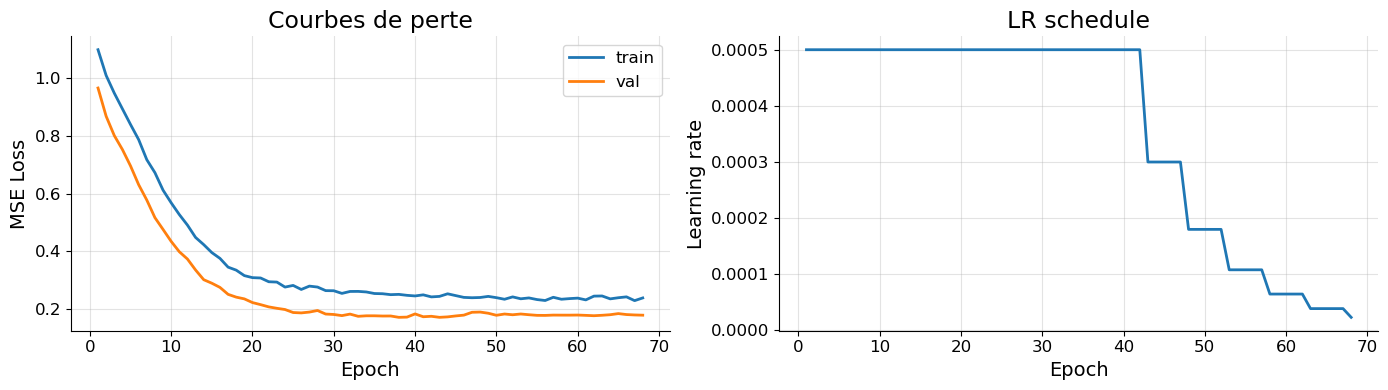

Entraînement terminé en 68 epochs.
Best val_loss = 0.171361


In [100]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
epochs_ran = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_ran, history["train_loss"], label="train")
ax1.plot(epochs_ran, history["val_loss"],   label="val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE Loss"); ax1.set_title("Courbes de perte")
ax1.legend(); ax1.grid(True)

ax2.plot(epochs_ran, history["lr"])
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning rate"); ax2.set_title("LR schedule")
ax2.grid(True)

plt.tight_layout(); plt.show()
print(f"Entraînement terminé en {len(history['train_loss'])} epochs.")
print(f"Best val_loss = {early_stopper.best_loss:.6f}")


In [101]:
def ensure_3d_output(arr, n_wells, horizon):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        assert arr.shape[1] == n_wells and arr.shape[2] == horizon
        return arr
    if arr.ndim == 2:
        assert arr.shape[1] == horizon
        assert arr.shape[0] % n_wells == 0
        return arr.reshape(arr.shape[0] // n_wells, n_wells, horizon)
    raise ValueError(f"Array ndim non supporté: {arr.ndim}")

@torch.no_grad()
def collect_predictions(mdl, loader):
    mdl.eval()
    preds_scaled, trues_scaled, preds_real, trues_real, metas = [], [], [], [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        dow_t = batch.dow.to(DEVICE) if hasattr(batch.dow, "to") else torch.tensor(batch.dow, dtype=torch.long).to(DEVICE)
        pred  = mdl(
            batch.x, batch.edge_index, batch.edge_attr, batch.well_mask,
            dow=dow_t if use_day_embedding else None,
            batch_idx=batch.batch if use_day_embedding else None,
        )
        y_true = batch.y.view_as(pred)
        pred_np = pred.detach().cpu().numpy()
        true_np = y_true.detach().cpu().numpy()
        preds_scaled.append(pred_np)
        trues_scaled.append(true_np)
        preds_real.append(inverse_transform_targets(pred_np))
        trues_real.append(inverse_transform_targets(true_np))
        if hasattr(batch, "target_start_idx"):
            metas.append(batch.target_start_idx.detach().cpu().numpy())

    preds_scaled = np.concatenate(preds_scaled, axis=0)
    trues_scaled = np.concatenate(trues_scaled, axis=0)
    preds_real   = np.concatenate(preds_real,   axis=0)
    trues_real   = np.concatenate(trues_real,   axis=0)

    assert np.allclose(inverse_transform_targets(trues_scaled), trues_real, atol=1e-5)

    return {
        "preds_scaled": preds_scaled,
        "trues_scaled": trues_scaled,
        "preds_real"  : preds_real,
        "trues_real"  : trues_real,
        "metas"       : np.concatenate(metas, axis=0) if metas else None,
    }

train_out = collect_predictions(model, train_loader)
val_out   = collect_predictions(model, val_loader)
test_out  = collect_predictions(model, test_loader)

for split, out in [("train", train_out), ("val", val_out), ("test", test_out)]:
    print(f"{split} | preds_real={out['preds_real'].shape} | trues_real={out['trues_real'].shape}")


train | preds_real=(1084, 24) | trues_real=(1084, 24)
val | preds_real=(124, 24) | trues_real=(124, 24)
test | preds_real=(244, 24) | trues_real=(244, 24)


In [102]:
def diagnose_prediction_alignment(out, n_checks=5):
    assert out["metas"] is not None
    preds_3d = ensure_3d_output(out["preds_real"], N_WELLS, HOR)
    trues_3d = ensure_3d_output(out["trues_real"], N_WELLS, HOR)
    metas    = np.asarray(out["metas"]).reshape(-1)
    n = min(n_checks, len(metas), len(trues_3d))
    for k in range(n):
        ts0 = int(metas[k])
        expected = g_full[ts0 : ts0 + HOR, :].T
        assert np.allclose(expected, trues_3d[k], atol=1e-6), f"Erreur alignement k={k}"
        print(f"k={k} | target_start={ts0} | {ts_g[ts0]} → {ts_g[ts0+HOR-1]} | OK")

diagnose_prediction_alignment(test_out, n_checks=CONFIG["NUM_ALIGNMENT_CHECKS"])
print("Diagnostic d'alignement test OK.")


k=0 | target_start=7320 | 2024-11-01 00:00:00 → 2024-11-01 23:00:00 | OK
k=1 | target_start=7344 | 2024-11-02 00:00:00 → 2024-11-02 23:00:00 | OK
k=2 | target_start=7368 | 2024-11-03 00:00:00 → 2024-11-03 23:00:00 | OK
k=3 | target_start=7392 | 2024-11-04 00:00:00 → 2024-11-04 23:00:00 | OK
k=4 | target_start=7416 | 2024-11-05 00:00:00 → 2024-11-05 23:00:00 | OK
k=5 | target_start=7440 | 2024-11-06 00:00:00 → 2024-11-06 23:00:00 | OK
k=6 | target_start=7464 | 2024-11-07 00:00:00 → 2024-11-07 23:00:00 | OK
k=7 | target_start=7488 | 2024-11-08 00:00:00 → 2024-11-08 23:00:00 | OK
k=8 | target_start=7512 | 2024-11-09 00:00:00 → 2024-11-09 23:00:00 | OK
k=9 | target_start=7536 | 2024-11-10 00:00:00 → 2024-11-10 23:00:00 | OK
Diagnostic d'alignement test OK.


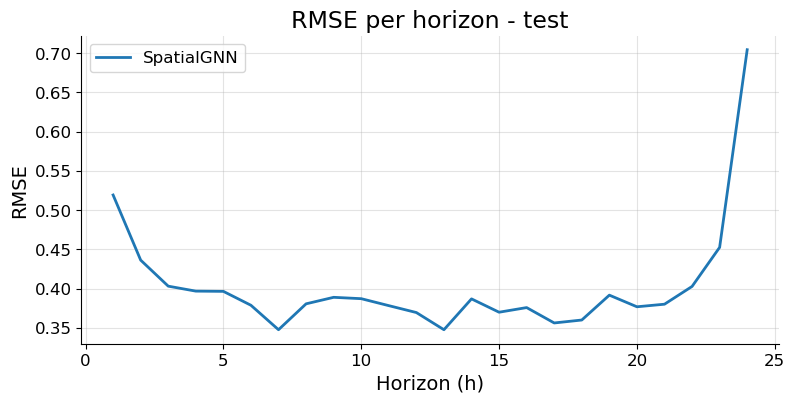

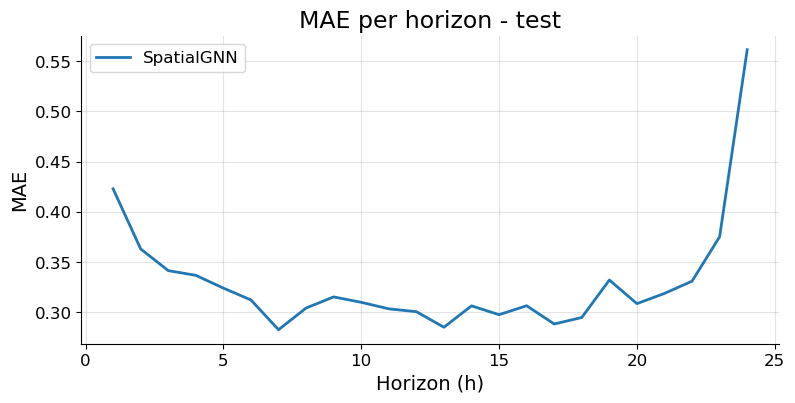

In [103]:
def per_horizon_metrics(y_true, y_pred):
    y_true_3d = ensure_3d_output(y_true, N_WELLS, HOR)
    y_pred_3d = ensure_3d_output(y_pred, N_WELLS, HOR)
    rows = []
    for h in range(HOR):
        m = mae_rmse_nmae(y_true_3d[:, :, h], y_pred_3d[:, :, h])
        rows.append({"h": h + 1, **m})
    return pd.DataFrame(rows)

test_horizon_df = per_horizon_metrics(test_out["trues_real"], test_out["preds_real"])

plt.figure(figsize=(9, 4))
plt.plot(test_horizon_df["h"], test_horizon_df["RMSE"], label="SpatialGNN")
plt.xlabel("Horizon (h)")
plt.ylabel("RMSE")
plt.title("RMSE per horizon - test")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(test_horizon_df["h"], test_horizon_df["MAE"], label="SpatialGNN")
plt.xlabel("Horizon (h)")
plt.ylabel("MAE")
plt.title("MAE per horizon - test")
plt.grid(True)
plt.legend()
plt.show()



In [104]:
T = len(ts_g)
true_cont = np.full((T, N_WELLS), np.nan)
pred_cont = np.full((T, N_WELLS), np.nan)

preds_3d = ensure_3d_output(test_out["preds_real"], N_WELLS, HOR)
metas = test_out["metas"]

assert metas is not None
assert len(metas) == len(preds_3d)

for k, ts0 in enumerate(metas):
    ts0 = int(ts0)
    for j in range(N_WELLS):
        true_cont[ts0 : ts0 + HOR, j] = g_full[ts0 : ts0 + HOR, j]
        pred_cont[ts0 : ts0 + HOR, j] = preds_3d[k, j, :]

n_valid = int(np.sum(np.any(~np.isnan(true_cont), axis=1)))
print(f"Continuous reconstruction: {n_valid} valid hours out of {T}")


Continuous reconstruction: 1464 valid hours out of 8784


72h zoom from 2024-11-01 00:00:00 to 2024-11-03 23:00:00


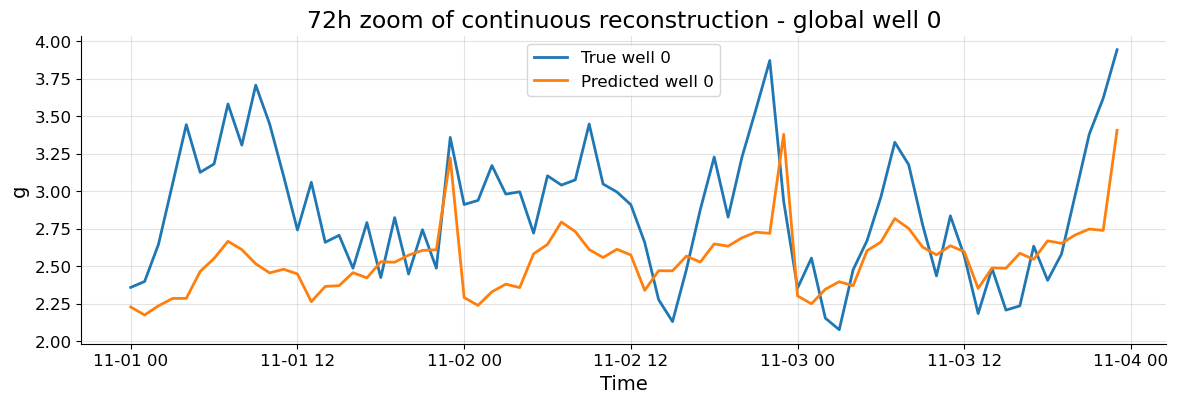

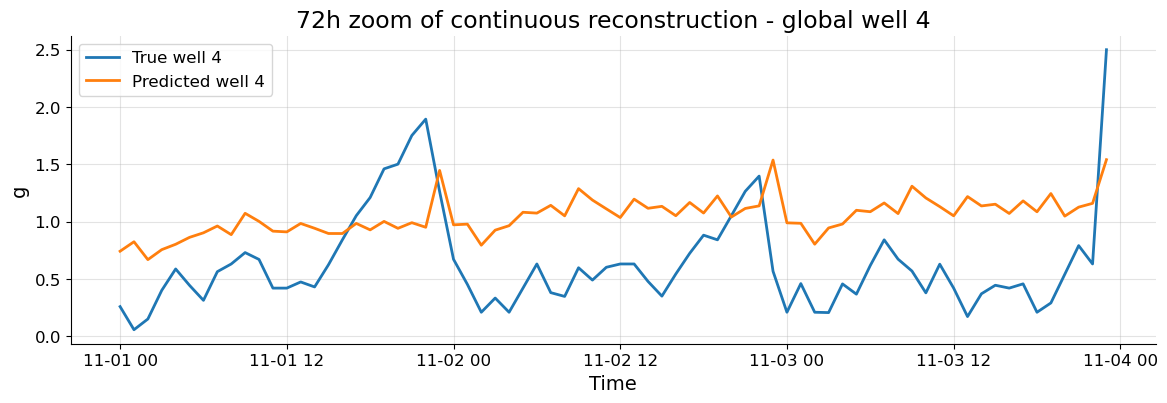

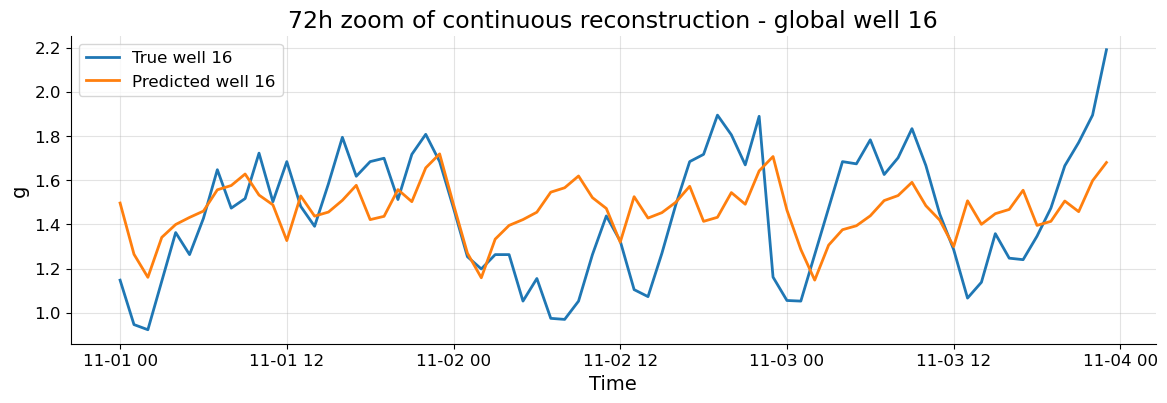

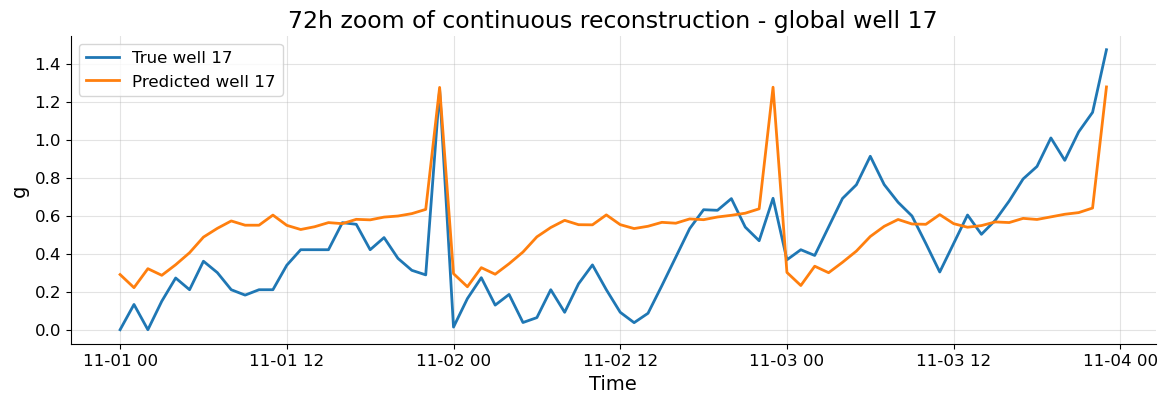

In [105]:
N_ZOOM = 72

valid_hours_mask = np.any(~np.isnan(true_cont), axis=1)
valid_idx = np.where(valid_hours_mask)[0]

start_plot = valid_idx[0]
end_plot = min(start_plot + N_ZOOM, T)

print("72h zoom from", ts_g[start_plot], "to", ts_g[end_plot - 1])

for j, w in enumerate(CONFIG["WELL_IDX"]):
    plt.figure(figsize=(14, 4))
    plt.plot(ts_g[start_plot:end_plot], true_cont[start_plot:end_plot, j], label=f"True well {w}")
    plt.plot(ts_g[start_plot:end_plot], pred_cont[start_plot:end_plot, j], label=f"Predicted well {w}")
    plt.title(f"72h zoom of continuous reconstruction - global well {w}")
    plt.xlabel("Time")
    plt.ylabel("g")
    plt.grid(True)
    plt.legend()
    plt.show()


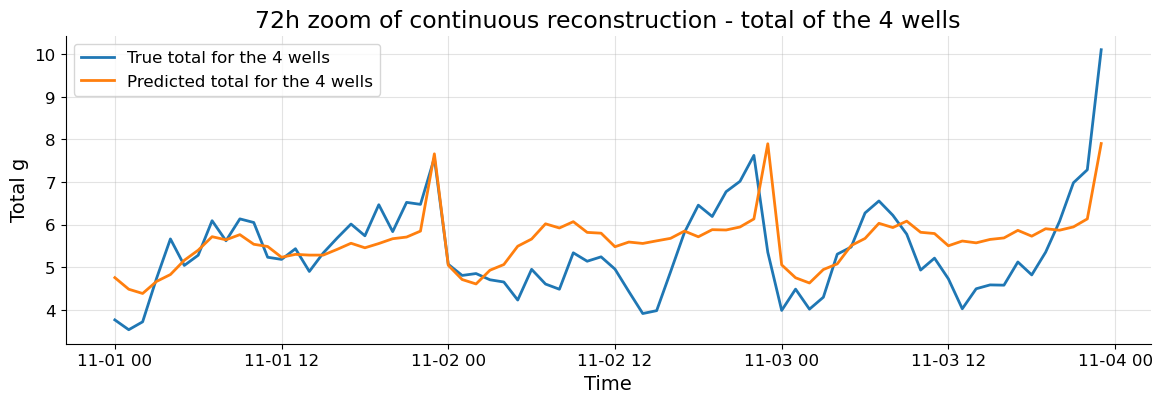

In [106]:
true_total_72h = np.nansum(true_cont[start_plot:end_plot, :], axis=1)
pred_total_72h = np.nansum(pred_cont[start_plot:end_plot, :], axis=1)

plt.figure(figsize=(14, 4))
plt.plot(ts_g[start_plot:end_plot], true_total_72h, label="True total for the 4 wells")
plt.plot(ts_g[start_plot:end_plot], pred_total_72h, label="Predicted total for the 4 wells")
plt.title("72h zoom of continuous reconstruction - total of the 4 wells")
plt.xlabel("Time")
plt.ylabel("Total g")
plt.grid(True)
plt.legend()
plt.show()


In [107]:
def aggregated_total_metrics(true_arr, pred_arr, n_wells, horizon):
    true_3d    = ensure_3d_output(true_arr, n_wells, horizon)
    pred_3d    = ensure_3d_output(pred_arr, n_wells, horizon)
    true_total = true_3d.sum(axis=1)
    pred_total = pred_3d.sum(axis=1)
    err_total  = pred_total - true_total
    mae_total  = np.mean(np.abs(err_total))
    rmse_total = np.sqrt(np.mean(err_total ** 2))
    mean_true  = np.mean(np.abs(true_total))
    return {
        "MAE_total_agg"          : mae_total,
        "RMSE_total_agg"         : rmse_total,
        "STD_error_total_agg"    : np.std(err_total),
        "mean_abs_true_total_agg": mean_true,
        "NMAE_total_agg"         : mae_total / (mean_true + 1e-12),
    }, true_total, pred_total, err_total

gnn_metrics_total,  gnn_true_total,  gnn_pred_total,  _ = aggregated_total_metrics(
    test_out["trues_real"], test_out["preds_real"], N_WELLS, HOR)

display(pd.DataFrame([
    {"model": "SpatialGasGNN", **gnn_metrics_total},
]))


,model,MAE_total_agg,RMSE_total_agg,STD_error_total_agg,mean_abs_true_total_agg,NMAE_total_agg
0,SpatialGasGNN,0.851673,1.066259,0.848439,5.216006,0.163281


=== GAZ ONLY | Global metrics on validation (g_total sur 4 wells) ===
MAE            : 0.601583
RMSE           : 0.814519
MAE/mean       : 0.127004
Roughness err  : 0.351654
Roughness true : 0.642459
Roughness pred : 0.290804


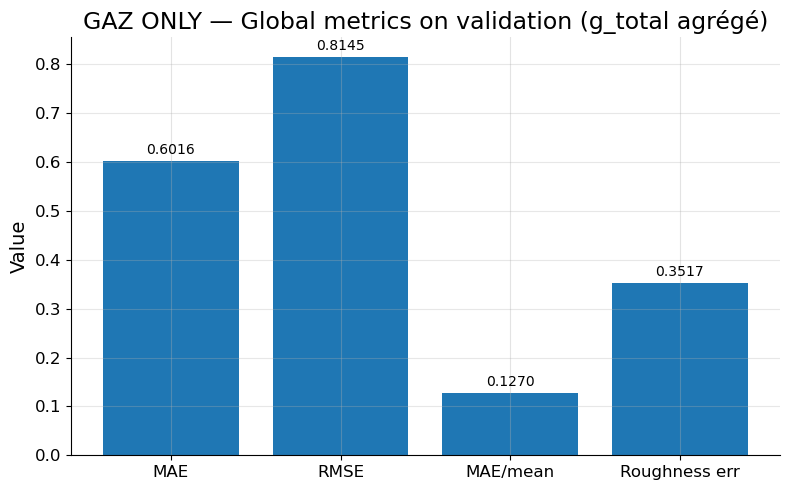

Figure saved to: C:\Users\yoans\TFE - GAZ\figures\global_metrics_gaz_only_val.png


In [89]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true).reshape(-1) - np.asarray(y_pred).reshape(-1)) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true).reshape(-1) - np.asarray(y_pred).reshape(-1))))

def roughness(x):
    x = np.asarray(x).reshape(-1)
    return float(np.mean(np.abs(np.diff(x)))) if len(x) >= 2 else 0.0

pred_real_3d = ensure_3d_output(val_out["preds_real"], N_WELLS, HOR)
true_real_3d = ensure_3d_output(val_out["trues_real"], N_WELLS, HOR)
g_pred_total = pred_real_3d.sum(axis=1).reshape(-1)
g_true_total = true_real_3d.sum(axis=1).reshape(-1)

metric_mae  = mae(g_true_total, g_pred_total)
metric_rmse = rmse(g_true_total, g_pred_total)
rough_true  = roughness(g_true_total)
rough_pred  = roughness(g_pred_total)

metrics_val = {
    "MAE"         : metric_mae,
    "RMSE"        : metric_rmse,
    "MAE/mean"    : metric_mae / (np.mean(np.abs(g_true_total)) + 1e-12),
    "Roughness err": abs(rough_pred - rough_true),
}

print("=== GAZ ONLY | Global metrics on validation (g_total sur 4 wells) ===")
for k, v in metrics_val.items():
    print(f"{k:<15}: {v:.6f}")
print(f"{'Roughness true':<15}: {rough_true:.6f}")
print(f"{'Roughness pred':<15}: {rough_pred:.6f}")

names, values = list(metrics_val.keys()), list(metrics_val.values())
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, values)
ax.set_title("GAZ ONLY — Global metrics on validation (g_total agrégé)")
ax.set_ylabel("Value"); ax.grid(True, axis="y", alpha=0.3)
ymax = max(values) if values else 1.0
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01 * ymax,
            f"{v:.4f}", ha="center", va="bottom", fontsize=10)
fig.tight_layout()

save_dir  = CONFIG["BASE_DIR"] / "figures"
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "global_metrics_gaz_only_val.png"
fig.savefig(save_path, dpi=140, bbox_inches="tight")
plt.show()
print("Figure saved to:", save_path.resolve())


Global STD true: 0.8148  pred: 0.6739
Aggregated total STD true: 1.1797  pred: 0.6338

Most under-variable wells:
  Well 00 | std_true=0.5057 | std_pred=0.2085 | diff=-0.2972
  Well 01 | std_true=0.4318 | std_pred=0.1927 | diff=-0.2391
  Well 02 | std_true=0.3096 | std_pred=0.1200 | diff=-0.1896
  Well 03 | std_true=0.2985 | std_pred=0.1909 | diff=-0.1076

Most over-variable wells:
  Well 00 | std_true=0.5057 | std_pred=0.2085 | diff=-0.2972
  Well 01 | std_true=0.4318 | std_pred=0.1927 | diff=-0.2391
  Well 02 | std_true=0.3096 | std_pred=0.1200 | diff=-0.1896
  Well 03 | std_true=0.2985 | std_pred=0.1909 | diff=-0.1076


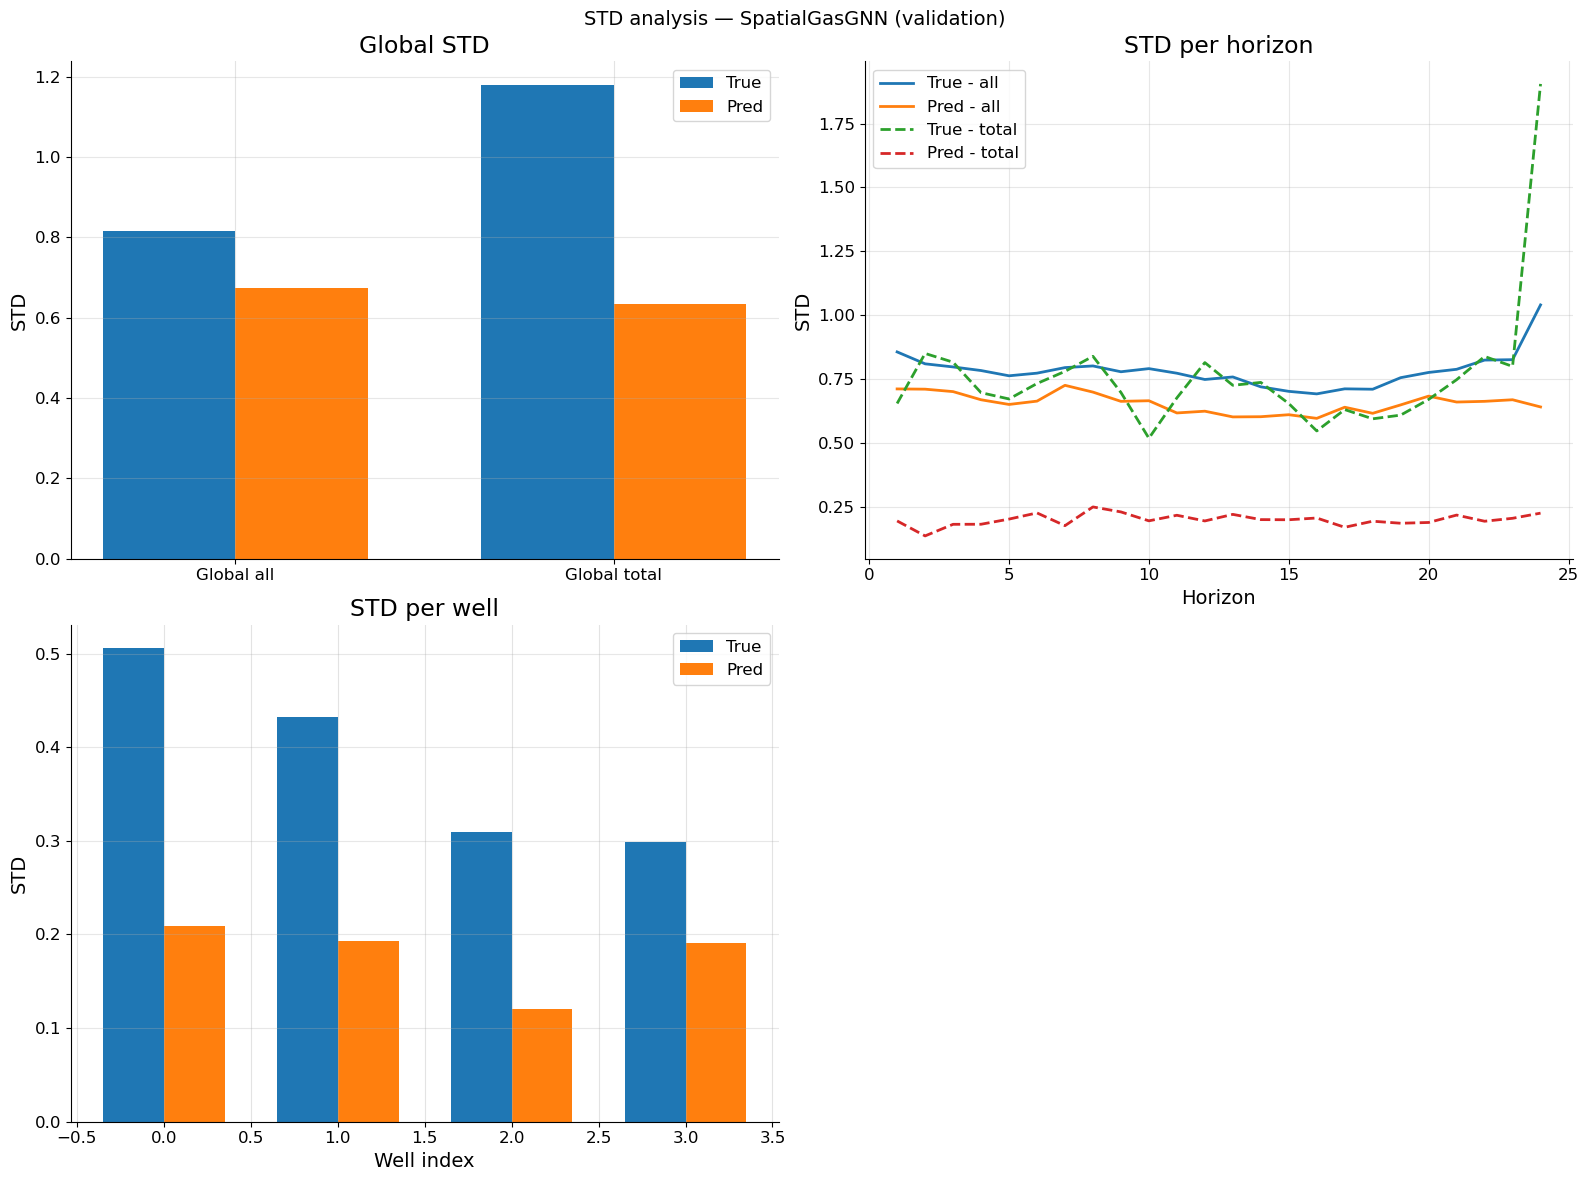

In [90]:
pred_3d = ensure_3d_output(val_out["preds_real"], N_WELLS, HOR)
true_3d = ensure_3d_output(val_out["trues_real"], N_WELLS, HOR)

std_true_global       = float(np.std(true_3d))
std_pred_global       = float(np.std(pred_3d))
true_total_v          = true_3d.sum(axis=1)
pred_total_v          = pred_3d.sum(axis=1)
std_true_total_global = float(np.std(true_total_v))
std_pred_total_global = float(np.std(pred_total_v))

std_true_h       = np.std(true_3d, axis=(0, 1))
std_pred_h       = np.std(pred_3d, axis=(0, 1))
std_true_total_h = np.std(true_total_v, axis=0)
std_pred_total_h = np.std(pred_total_v, axis=0)
std_true_well    = np.std(true_3d, axis=(0, 2))
std_pred_well    = np.std(pred_3d, axis=(0, 2))
std_diff_well_h  = np.std(pred_3d, axis=0) - np.std(true_3d, axis=0)

print(f"Global STD true: {std_true_global:.4f}  pred: {std_pred_global:.4f}")
print(f"Aggregated total STD true: {std_true_total_global:.4f}  pred: {std_pred_total_global:.4f}")

well_diff = std_pred_well - std_true_well
for label, idxs in [("under-variable", np.argsort(well_diff)[:N_WELLS]),
                    ("over-variable",  np.argsort(well_diff)[-N_WELLS:])]:
    print(f"\nMost {label} wells:")
    for idx in idxs:
        print(f"  Well {idx:02d} | std_true={std_true_well[idx]:.4f} | std_pred={std_pred_well[idx]:.4f} | diff={well_diff[idx]:.4f}")

fig = plt.figure(figsize=(16, 12))
w = 0.35

ax1 = plt.subplot(2, 2, 1)
labels = ["Global all", "Global total"]
ax1.bar(np.arange(2) - w/2, [std_true_global, std_true_total_global], width=w, label="True")
ax1.bar(np.arange(2) + w/2, [std_pred_global, std_pred_total_global], width=w, label="Pred")
ax1.set_xticks(np.arange(2)); ax1.set_xticklabels(labels)
ax1.set_title("Global STD"); ax1.set_ylabel("STD"); ax1.grid(True, axis="y", alpha=0.3); ax1.legend()

ax2 = plt.subplot(2, 2, 2)
h = np.arange(1, HOR + 1)
ax2.plot(h, std_true_h, label="True - all"); ax2.plot(h, std_pred_h, label="Pred - all")
ax2.plot(h, std_true_total_h, linestyle="--", label="True - total")
ax2.plot(h, std_pred_total_h, linestyle="--", label="Pred - total")
ax2.set_title("STD per horizon"); ax2.set_xlabel("Horizon"); ax2.set_ylabel("STD")
ax2.grid(True, alpha=0.3); ax2.legend()

ax3 = plt.subplot(2, 2, 3)
wells = np.arange(N_WELLS)
ax3.bar(wells - w/2, std_true_well, width=w, label="True")
ax3.bar(wells + w/2, std_pred_well, width=w, label="Pred")
ax3.set_title("STD per well"); ax3.set_xlabel("Well index"); ax3.set_ylabel("STD")
ax3.grid(True, axis="y", alpha=0.3); ax3.legend()

fig.suptitle("STD analysis — SpatialGasGNN (validation)", fontsize=14)
fig.tight_layout(); plt.show()

In [91]:
N_WELLS_ = N_WELLS
HOR_ = HOR
test_out_ = test_out
dyn_feature_names_ = dyn_feature_names

def _to_3d_pred(arr, n_wells, hor):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        return arr
    if arr.ndim == 2:
        return arr.reshape(arr.shape[0] // n_wells, n_wells, hor)
    raise ValueError(f"Cannot reshape array with ndim={arr.ndim}")

def _mae_rmse(a, b):
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    return {
        "MAE": float(np.mean(np.abs(a - b))),
        "RMSE": float(np.sqrt(np.mean((a - b) ** 2)))
    }

print("Diagnostic aliases defined.")

Diagnostic aliases defined.


,well_local_idx,well_global_idx,MAE,RMSE,mean_abs_target,NMAE,std_true,std_pred,std_ratio_pred_true
0,0,0,0.362522,0.463148,2.569704,0.141075,0.512241,0.270865,0.528785
1,1,4,0.338794,0.427539,0.921857,0.367512,0.460088,0.258831,0.562568
3,3,17,0.355298,0.408183,0.224024,1.585984,0.250203,0.190081,0.759708
2,2,16,0.271532,0.329884,1.500422,0.180971,0.367491,0.121727,0.331238


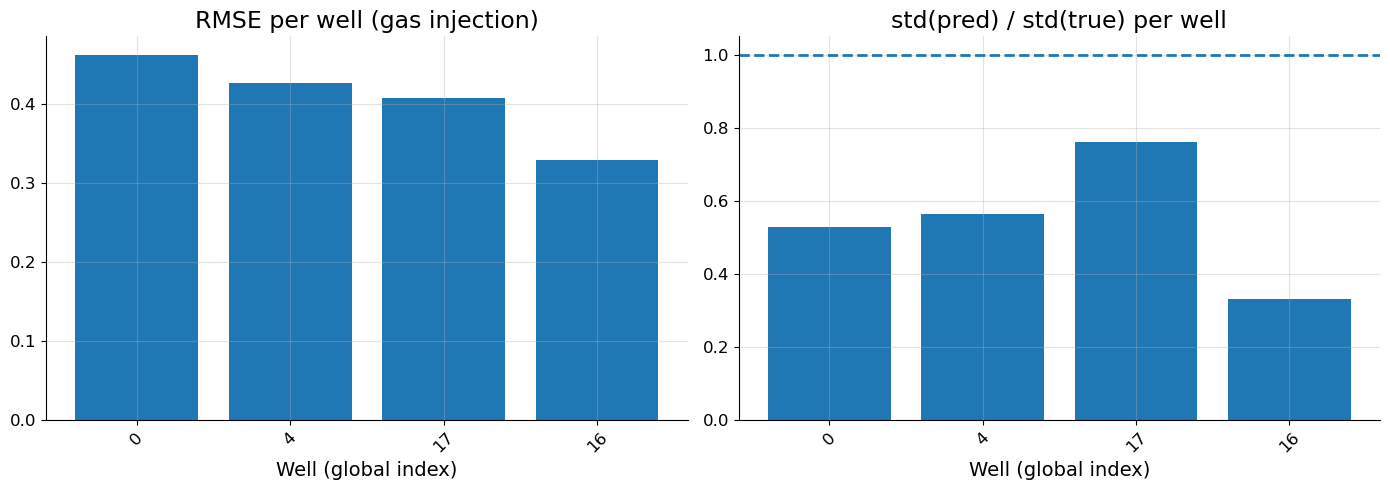

Worst wells (gas injection):


,well_local_idx,well_global_idx,MAE,RMSE,mean_abs_target,NMAE,std_true,std_pred,std_ratio_pred_true
0,0,0,0.362522,0.463148,2.569704,0.141075,0.512241,0.270865,0.528785
1,1,4,0.338794,0.427539,0.921857,0.367512,0.460088,0.258831,0.562568
3,3,17,0.355298,0.408183,0.224024,1.585984,0.250203,0.190081,0.759708
2,2,16,0.271532,0.329884,1.500422,0.180971,0.367491,0.121727,0.331238


In [92]:
y_true3 = _to_3d_pred(test_out["trues_real"], N_WELLS_, HOR_)
y_pred3 = _to_3d_pred(test_out["preds_real"], N_WELLS_, HOR_)

rows = []
for j in range(N_WELLS_):
    yt = y_true3[:, j, :]
    yp = y_pred3[:, j, :]
    m  = _mae_rmse(yt, yp)
    rows.append({
        "well_local_idx"      : j,
        "well_global_idx"     : CONFIG["WELL_IDX"][j],
        "MAE"                 : m["MAE"],
        "RMSE"                : m["RMSE"],
        "mean_abs_target"     : float(np.mean(np.abs(yt))),
        "NMAE"                : float(m["MAE"] / (np.mean(np.abs(yt)) + 1e-12)),
        "std_true"            : float(np.std(yt)),
        "std_pred"            : float(np.std(yp)),
        "std_ratio_pred_true" : float(np.std(yp) / (np.std(yt) + 1e-12)),
    })
node_df = pd.DataFrame(rows).sort_values("RMSE", ascending=False)
display(node_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(node_df["well_global_idx"].astype(str), node_df["RMSE"])
axes[0].set_title("RMSE per well (gas injection)")
axes[0].set_xlabel("Well (global index)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, axis="y")

axes[1].bar(node_df["well_global_idx"].astype(str), node_df["std_ratio_pred_true"])
axes[1].axhline(1.0, linestyle="--")
axes[1].set_title("std(pred) / std(true) per well")
axes[1].set_xlabel("Well (global index)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.show()

print("Worst wells (gas injection):")
display(node_df.head(10))

GIANT DIAGNOSTIC CELL — GNN Spatial Gas

--- SECTION : Error per prediction horizon (test set) ---


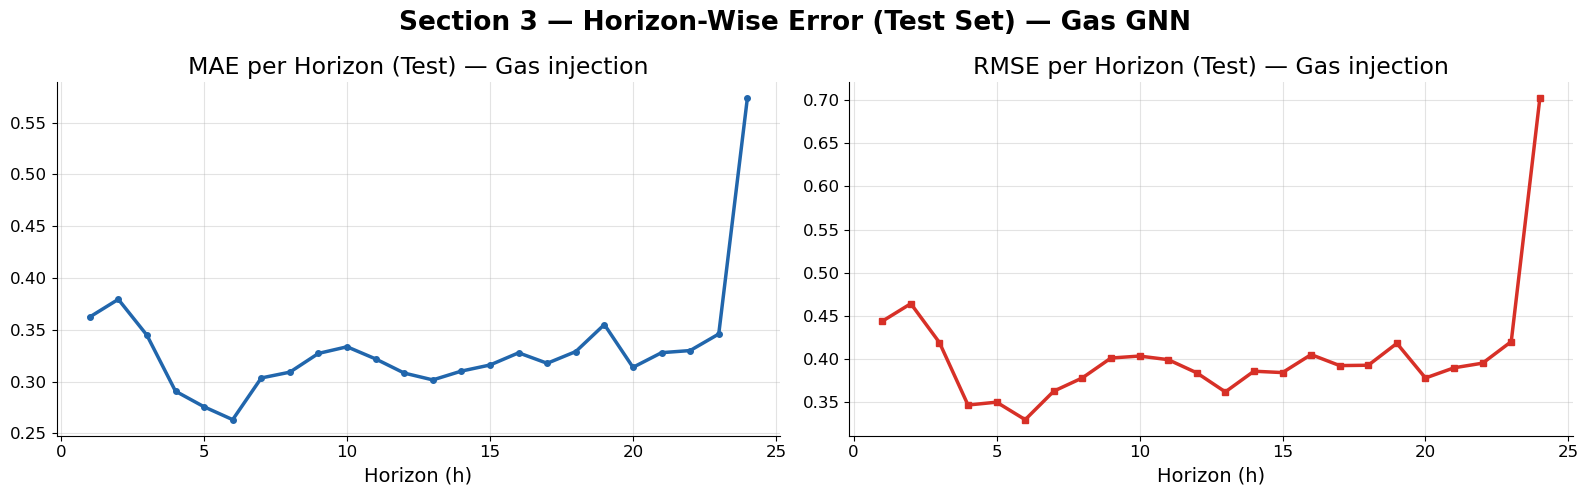

  RMSE h=1: 0.4436  |  RMSE h=24: 0.7022

--- SECTION : Smoothing analysis ---
  Mean per-well STD ratio : 0.546
  Aggregated STD ratio    : 0.592
  % wells with ratio < 0.8: 100.0%


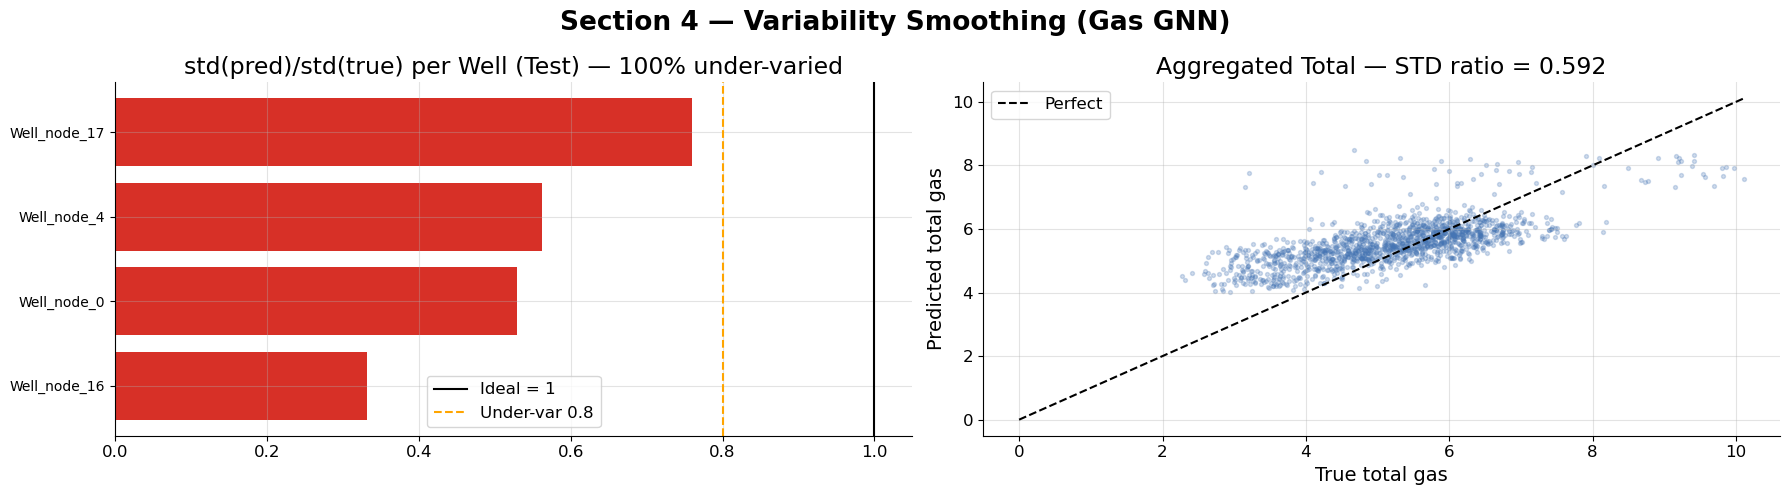


--- SECTION : Dynamic feature – target correlation (lag = horizon) ---
      feature  corr_t+24h
   res_demand    0.574253
gfpp_gas_load    0.397138
   ind_demand    0.332018


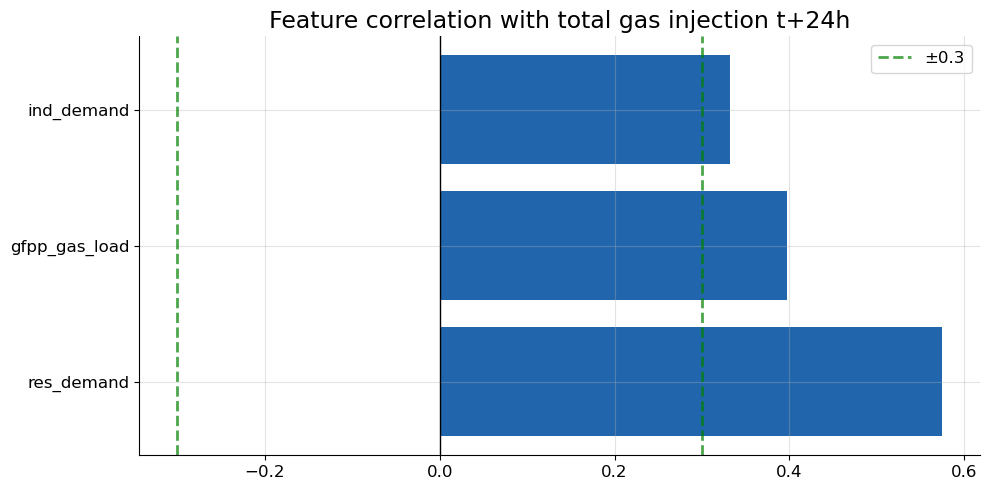

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

plt.rcParams.update({
    "figure.figsize": (14, 5), "axes.titlesize": 17, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "figure.titlesize": 19, "lines.linewidth": 2.0, "axes.grid": True,
    "grid.alpha": 0.35, "axes.spines.top": False, "axes.spines.right": False,
})

def _get(*names, default=None):
    for n in names:
        if n in globals(): return globals()[n]
    return default

def _to3d(arr, n_wells, hor):
    arr = np.asarray(arr)
    if arr.ndim == 3: return arr
    if arr.ndim == 2: return arr.reshape(arr.shape[0] // n_wells, n_wells, hor)
    raise ValueError(f"Cannot reshape ndim={arr.ndim}")

def _mae(a, b):
    return float(np.mean(np.abs(np.asarray(a).ravel() - np.asarray(b).ravel())))

def _rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a).ravel() - np.asarray(b).ravel())**2)))

CONFIG_   = _get("CONFIG", default={})
N_WELLS_  = _get("N_WELLS", default=len(CONFIG_.get("WELL_IDX", [0,4,16,17])))
HOR_      = _get("HOR", "HORIZON_HOURS", default=24)
WELL_IDX_ = list(CONFIG_.get("WELL_IDX", list(range(N_WELLS_))))
ts_       = np.asarray(_get("ts_g", "ts", default=np.arange(8784)))
train_out_ = _get("train_out"); val_out_ = _get("val_out"); test_out_ = _get("test_out")
g_full_    = _get("g_full")
dyn_tensor_ = _get("dyn_tensor"); dyn_feature_names_ = _get("dyn_feature_names")
history_   = _get("history")

def well_name(global_idx): return f"Well_node_{global_idx}"

def autocorr_1d(y, lag=1):
    y = np.asarray(y, dtype=float)
    valid = y[~np.isnan(y)]
    if len(valid) <= lag: return np.nan
    return float(np.corrcoef(valid[:-lag], valid[lag:])[0, 1])


print("GIANT DIAGNOSTIC CELL — GNN Spatial Gas")



# ── Section : Error by horizon ──────────────────────────────────────────────
print("\n--- SECTION : Error per prediction horizon (test set) ---")
if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_WELLS_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_WELLS_, HOR_)
    hor_df  = pd.DataFrame([{"h": h+1, "model_MAE": _mae(y_true3[:,:,h], y_pred3[:,:,h]),
                              "model_RMSE": _rmse(y_true3[:,:,h], y_pred3[:,:,h])}
                             for h in range(HOR_)])
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(hor_df["h"], hor_df["model_MAE"],  color="#2166ac", lw=2.5, marker="o", ms=4)
    axes[0].set_title("MAE per Horizon (Test) — Gas injection"); axes[0].set_xlabel("Horizon (h)")
    axes[1].plot(hor_df["h"], hor_df["model_RMSE"], color="#d73027", lw=2.5, marker="s", ms=4)
    axes[1].set_title("RMSE per Horizon (Test) — Gas injection"); axes[1].set_xlabel("Horizon (h)")
    plt.suptitle("Section 3 — Horizon-Wise Error (Test Set) — Gas GNN", fontweight="bold")
    plt.tight_layout(); plt.show()
    print(f"  RMSE h=1: {hor_df.iloc[0]['model_RMSE']:.4f}  |  RMSE h=24: {hor_df.iloc[-1]['model_RMSE']:.4f}")

# ── Section : STD ratio per well ────────────────────────────────────────────
print("\n--- SECTION : Smoothing analysis ---")
if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_WELLS_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_WELLS_, HOR_)
    node_std_rows = []
    for j in range(N_WELLS_):
        std_t  = float(np.std(y_true3[:, j, :]))
        std_p  = float(np.std(y_pred3[:, j, :]))
        w_idx  = WELL_IDX_[j] if j < len(WELL_IDX_) else j
        node_std_rows.append({"well_j": j, "global_well_idx": w_idx,
                               "well_name": well_name(w_idx),
                               "std_true": std_t, "std_pred": std_p,
                               "ratio": std_p / (std_t + 1e-9)})
    node_std_df = pd.DataFrame(node_std_rows).sort_values("ratio")
    pct_under   = float((node_std_df["ratio"] < 0.8).mean()) * 100
    agg_true    = y_true3.sum(axis=1); agg_pred = y_pred3.sum(axis=1)
    agg_std_ratio = float(np.std(agg_pred)) / (float(np.std(agg_true)) + 1e-9)
    print(f"  Mean per-well STD ratio : {node_std_df['ratio'].mean():.3f}")
    print(f"  Aggregated STD ratio    : {agg_std_ratio:.3f}")
    print(f"  % wells with ratio < 0.8: {pct_under:.1f}%")
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    colors_bar = ["#d73027" if r < 0.8 else "#4d9221" for r in node_std_df["ratio"]]
    axes[0].barh(range(len(node_std_df)), node_std_df["ratio"], color=colors_bar)
    axes[0].axvline(1.0, color="black", ls="-", lw=1.5, label="Ideal = 1")
    axes[0].axvline(0.8, color="orange", ls="--", lw=1.5, label="Under-var 0.8")
    axes[0].set_yticks(range(len(node_std_df))); axes[0].set_yticklabels(node_std_df["well_name"].values, fontsize=10)
    axes[0].set_title(f"std(pred)/std(true) per Well (Test) — {pct_under:.0f}% under-varied"); axes[0].legend()
    n_samp = min(3000, len(agg_true.ravel()))
    idx_s  = np.random.choice(len(agg_true.ravel()), n_samp, replace=False)
    lim    = max(np.abs(agg_true.ravel()).max(), np.abs(agg_pred.ravel()).max())
    axes[1].scatter(agg_true.ravel()[idx_s], agg_pred.ravel()[idx_s], alpha=0.25, s=8, color="#4575b4")
    axes[1].plot([0, lim], [0, lim], "k--", lw=1.5, label="Perfect")
    axes[1].set_title(f"Aggregated Total — STD ratio = {agg_std_ratio:.3f}")
    axes[1].set_xlabel("True total gas"); axes[1].set_ylabel("Predicted total gas"); axes[1].legend()
    plt.suptitle("Section 4 — Variability Smoothing (Gas GNN)", fontweight="bold")
    plt.tight_layout(); plt.show()

# ── Section : Feature-target correlation ────────────────────────────────────
print("\n--- SECTION : Dynamic feature – target correlation (lag = horizon) ---")
if dyn_tensor_ is not None and g_full_ is not None:
    T_data     = min(dyn_tensor_.shape[0], g_full_.shape[0])
    F_dyn      = dyn_tensor_.shape[-1]
    feat_names = dyn_feature_names_ if dyn_feature_names_ is not None else [f"dyn_{i}" for i in range(F_dyn)]
    target_total = np.nansum(g_full_[:T_data], axis=1)
    lag = HOR_
    corr_rows = []
    for k in range(F_dyn):
        feat_mean = np.nanmean(dyn_tensor_[:T_data, :, k], axis=1)
        valid = ~(np.isnan(feat_mean) | np.isnan(target_total))
        x, y  = feat_mean[valid], target_total[valid]
        corr_val = float(np.corrcoef(x[:-lag], y[lag:])[0, 1]) if len(x) > lag + 10 else np.nan
        corr_rows.append({"feature": feat_names[k], f"corr_t+{lag}h": corr_val})
    corr_df  = pd.DataFrame(corr_rows).sort_values(f"corr_t+{lag}h", key=abs, ascending=False)
    col_key  = f"corr_t+{lag}h"
    print(corr_df.to_string(index=False))
    fig, ax = plt.subplots(figsize=(10, 5))
    colors_c = ["#2166ac" if abs(v) > 0.3 else "#d73027" for v in corr_df[col_key]]
    ax.barh(corr_df["feature"], corr_df[col_key], color=colors_c)
    ax.axvline(0.0, color="black", lw=1)
    ax.axvline(0.3, color="green", ls="--", alpha=0.7, label="±0.3")
    ax.axvline(-0.3, color="green", ls="--", alpha=0.7)
    ax.set_title(f"Feature correlation with total gas injection t+{lag}h"); ax.legend()
    plt.tight_layout(); plt.show()




In [ ]:
class NoMessagePassingGas(nn.Module):
    def __init__(self, in_dim, hidden_dim, horizon,
                 encoder_hidden_dims=(256, 128), decoder_hidden_dims=(128, 64),
                 dropout=0.0, use_batchnorm=True,
                 use_day_embedding=False, day_emb_dim=3):
        super().__init__()
        self.use_day_embedding = use_day_embedding
        if use_day_embedding:
            self.day_embedding = nn.Embedding(7, day_emb_dim)
            enc_in_dim = in_dim + day_emb_dim
        else:
            enc_in_dim = in_dim

        enc_dims = [enc_in_dim] + list(encoder_hidden_dims) + [hidden_dim]
        self.encoder = MLP(enc_dims, dropout=dropout, use_batchnorm=use_batchnorm, activate_last=False)

        dec_dims = [hidden_dim] + list(decoder_hidden_dims) + [horizon]
        self.decoder = MLP(dec_dims, dropout=dropout, use_batchnorm=use_batchnorm, activate_last=False)

    def forward(self, x, edge_index, edge_attr, well_mask, dow=None, batch_idx=None):
        if self.use_day_embedding and dow is not None and batch_idx is not None:
            dow_emb = self.day_embedding(dow)
            x = torch.cat([x, dow_emb[batch_idx]], dim=1)

        h = self.encoder(x)
        h_wells = h[well_mask]
        return self.decoder(h_wells)


ablation_model = NoMessagePassingGas(
    in_dim              = expected_x_dim,
    hidden_dim          = CONFIG["HIDDEN_DIM"],
    horizon             = HOR,
    encoder_hidden_dims = CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims = CONFIG["DECODER_HIDDEN_DIMS"],
    dropout             = CONFIG["DROPOUT"],
    use_batchnorm       = CONFIG["USE_BATCHNORM"],
    use_day_embedding   = use_day_embedding,
    day_emb_dim         = day_emb_dim,
).to(DEVICE)

ablation_optimizer = torch.optim.Adam(
    ablation_model.parameters(),
    lr=CONFIG["LR"],
    weight_decay=CONFIG["WEIGHT_DECAY"]
)

ablation_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    ablation_optimizer,
    mode="min",
    factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"],
    min_lr=CONFIG["SCHEDULER_MIN_LR"]
)

ablation_early_stopper = EarlyStopping(
    patience=CONFIG["EARLY_STOPPING_PATIENCE"],
    min_delta=CONFIG["EARLY_STOPPING_MIN_DELTA"]
)

ablation_history = {"train_loss": [], "val_loss": [], "lr": []}

print("=== No-message-passing model (Gas) ===")
print(ablation_model)

for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss = run_one_epoch(ablation_model, train_loader, optimizer=ablation_optimizer)
    val_loss   = run_one_epoch(ablation_model, val_loader, optimizer=None)

    ablation_scheduler.step(val_loss)
    current_lr = ablation_optimizer.param_groups[0]["lr"]

    ablation_history["train_loss"].append(train_loss)
    ablation_history["val_loss"].append(val_loss)
    ablation_history["lr"].append(current_lr)

    print(f"[NoMP] Epoch {epoch:03d} | train={train_loss:.6f} | val={val_loss:.6f} | lr={current_lr:.2e}")

    if ablation_early_stopper.step(val_loss, ablation_model):
        print(f"[NoMP] Early stopping at epoch {epoch}.")
        break

assert ablation_early_stopper.best_state is not None
ablation_model.load_state_dict(ablation_early_stopper.best_state)

print("\n[NoMP] Best val_loss:", ablation_early_stopper.best_loss)

ablation_train_out = collect_predictions(ablation_model, train_loader)
ablation_val_out   = collect_predictions(ablation_model, val_loader)
ablation_test_out  = collect_predictions(ablation_model, test_loader)


def evaluate_output_dict_custom(out, split_name, model_prefix):
    preds_3d = ensure_3d_output(out["preds_real"], N_WELLS, HOR)
    trues_3d = ensure_3d_output(out["trues_real"], N_WELLS, HOR)

    rows = []

    m = mae_rmse_nmae(trues_3d, preds_3d)
    m.update({"split": split_name, "model": f"{model_prefix}_global"})
    rows.append(m)

    for j, w_idx in enumerate(CONFIG["WELL_IDX"]):
        m = mae_rmse_nmae(trues_3d[:, j, :], preds_3d[:, j, :])
        m.update({
            "split": split_name,
            "model": f"{model_prefix}_well_{w_idx}",
            "well_global_idx": w_idx,
            "well_name": f"well_node_{w_idx}"
        })
        rows.append(m)

    return pd.DataFrame(rows)


ablation_metrics_df = pd.concat([
    evaluate_output_dict_custom(ablation_train_out, "train", "NoMP"),
    evaluate_output_dict_custom(ablation_val_out,   "val",   "NoMP"),
    evaluate_output_dict_custom(ablation_test_out,  "test",  "NoMP"),
], ignore_index=True)

display(ablation_metrics_df)

comparison_rows = []


In [95]:
def aggregate_totals_per_hour(arr, n_wells, horizon):
    return ensure_3d_output(arr, n_wells, horizon).sum(axis=1)

gnn_test_pred_tot  = aggregate_totals_per_hour(test_out["preds_real"],         N_WELLS, HOR)
gnn_test_true_tot  = aggregate_totals_per_hour(test_out["trues_real"],         N_WELLS, HOR)
nomp_test_pred_tot = aggregate_totals_per_hour(ablation_test_out["preds_real"], N_WELLS, HOR)
nomp_test_true_tot = aggregate_totals_per_hour(ablation_test_out["trues_real"], N_WELLS, HOR)

rows = []
for label, true_tot, pred_tot in [
    ("SpatialGasGNN_aggregated_total",    gnn_test_true_tot,  gnn_test_pred_tot),
    ("NoMessagePassing_aggregated_total", nomp_test_true_tot, nomp_test_pred_tot),
]:
    m = mae_rmse_nmae(true_tot, pred_tot)
    m["model"] = label
    rows.append(m)

agg_total_df = pd.DataFrame(rows)[["model", "MAE", "RMSE", "NMAE"]].sort_values("RMSE").reset_index(drop=True)

print("=== TEST comparison on AGGREGATED TOTALS (gas injection) ===")
display(agg_total_df)

gnn_rmse  = agg_total_df.loc[agg_total_df["model"] == "SpatialGasGNN_aggregated_total", "RMSE"]
nomp_rmse = agg_total_df.loc[agg_total_df["model"] == "NoMessagePassing_aggregated_total", "RMSE"]

if len(gnn_rmse) and len(nomp_rmse):
    rel_gap = 100 * (nomp_rmse.iloc[0] - gnn_rmse.iloc[0]) / max(abs(gnn_rmse.iloc[0]), 1e-12)
    print(f"Relative RMSE gap NoMP vs GNN on gas aggregated totals = {rel_gap:.2f}%")

=== TEST comparison on AGGREGATED TOTALS (gas injection) ===


,model,MAE,RMSE,NMAE
0,SpatialGasGNN_aggregated_total,0.735435,0.937117,0.140996
1,NoMessagePassing_aggregated_total,0.884946,1.082031,0.169660


Relative RMSE gap NoMP vs GNN on gas aggregated totals = 15.46%


In [96]:
def roughness(x):
    x = np.asarray(x).reshape(-1)
    return float(np.mean(np.abs(np.diff(x)))) if len(x) >= 2 else 0.0

rows = []
for label, true_tot, pred_tot in [
    ("SpatialGasGNN",   gnn_test_true_tot,  gnn_test_pred_tot),
    ("NoMessagePassing",nomp_test_true_tot, nomp_test_pred_tot),
]:
    rows.append({
        "model"      : label,
        "rough_true" : roughness(true_tot),
        "rough_pred" : roughness(pred_tot),
        "rough_error": roughness(pred_tot - true_tot),
    })

roughness_df = pd.DataFrame(rows)
roughness_df["pred_minus_true"] = roughness_df["rough_pred"] - roughness_df["rough_true"]
roughness_df["pred_over_true"]  = roughness_df["rough_pred"] / np.maximum(roughness_df["rough_true"], 1e-12)
print("=== Roughness sur les TOTAUX AGRÉGÉS — injection gaz (TEST) ===")
display(roughness_df)

print("\n=== Lecture rapide ===")
for _, r in roughness_df.iterrows():
    print(f"{r['model']}:")
    print(f"  rough_true={r['rough_true']:.4f}  rough_pred={r['rough_pred']:.4f}  pred/true={r['pred_over_true']:.3f}")


=== Roughness sur les TOTAUX AGRÉGÉS — injection gaz (TEST) ===


,model,rough_true,rough_pred,rough_error,pred_minus_true,pred_over_true
0,SpatialGasGNN,0.599118,0.328602,0.490433,-0.270515,0.548477
1,NoMessagePassing,0.599118,0.354311,0.503218,-0.244806,0.591388



=== Lecture rapide ===
SpatialGasGNN:
  rough_true=0.5991  rough_pred=0.3286  pred/true=0.548
NoMessagePassing:
  rough_true=0.5991  rough_pred=0.3543  pred/true=0.591


In [94]:
class NoMessagePassingGas(nn.Module):
    def __init__(self, in_dim, hidden_dim, horizon,
                 encoder_hidden_dims=(256, 128), decoder_hidden_dims=(128, 64),
                 dropout=0.0, use_batchnorm=True,
                 use_day_embedding=False, day_emb_dim=3):
        super().__init__()
        self.use_day_embedding = use_day_embedding
        if use_day_embedding:
            self.day_embedding = nn.Embedding(7, day_emb_dim)
            enc_in_dim = in_dim + day_emb_dim
        else:
            enc_in_dim = in_dim

        enc_dims = [enc_in_dim] + list(encoder_hidden_dims) + [hidden_dim]
        self.encoder = MLP(enc_dims, dropout=dropout, use_batchnorm=use_batchnorm, activate_last=False)

        dec_dims = [hidden_dim] + list(decoder_hidden_dims) + [horizon]
        self.decoder = MLP(dec_dims, dropout=dropout, use_batchnorm=use_batchnorm, activate_last=False)

    def forward(self, x, edge_index, edge_attr, well_mask, dow=None, batch_idx=None):
        if self.use_day_embedding and dow is not None and batch_idx is not None:
            dow_emb = self.day_embedding(dow)
            x = torch.cat([x, dow_emb[batch_idx]], dim=1)

        h = self.encoder(x)
        h_wells = h[well_mask]
        return self.decoder(h_wells)


ablation_model = NoMessagePassingGas(
    in_dim              = expected_x_dim,
    hidden_dim          = CONFIG["HIDDEN_DIM"],
    horizon             = HOR,
    encoder_hidden_dims = CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims = CONFIG["DECODER_HIDDEN_DIMS"],
    dropout             = CONFIG["DROPOUT"],
    use_batchnorm       = CONFIG["USE_BATCHNORM"],
    use_day_embedding   = use_day_embedding,
    day_emb_dim         = day_emb_dim,
).to(DEVICE)

ablation_optimizer = torch.optim.Adam(
    ablation_model.parameters(),
    lr=CONFIG["LR"],
    weight_decay=CONFIG["WEIGHT_DECAY"]
)

ablation_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    ablation_optimizer,
    mode="min",
    factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"],
    min_lr=CONFIG["SCHEDULER_MIN_LR"]
)

ablation_early_stopper = EarlyStopping(
    patience=CONFIG["EARLY_STOPPING_PATIENCE"],
    min_delta=CONFIG["EARLY_STOPPING_MIN_DELTA"]
)

ablation_history = {"train_loss": [], "val_loss": [], "lr": []}

print("=== No-message-passing model (Gas) ===")
print(ablation_model)

for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss = run_one_epoch(ablation_model, train_loader, optimizer=ablation_optimizer)
    val_loss   = run_one_epoch(ablation_model, val_loader, optimizer=None)

    ablation_scheduler.step(val_loss)
    current_lr = ablation_optimizer.param_groups[0]["lr"]

    ablation_history["train_loss"].append(train_loss)
    ablation_history["val_loss"].append(val_loss)
    ablation_history["lr"].append(current_lr)

    print(f"[NoMP] Epoch {epoch:03d} | train={train_loss:.6f} | val={val_loss:.6f} | lr={current_lr:.2e}")

    if ablation_early_stopper.step(val_loss, ablation_model):
        print(f"[NoMP] Early stopping at epoch {epoch}.")
        break

assert ablation_early_stopper.best_state is not None
ablation_model.load_state_dict(ablation_early_stopper.best_state)

print("\n[NoMP] Best val_loss:", ablation_early_stopper.best_loss)

ablation_train_out = collect_predictions(ablation_model, train_loader)
ablation_val_out   = collect_predictions(ablation_model, val_loader)
ablation_test_out  = collect_predictions(ablation_model, test_loader)


def evaluate_output_dict_custom(out, split_name, model_prefix):
    preds_3d = ensure_3d_output(out["preds_real"], N_WELLS, HOR)
    trues_3d = ensure_3d_output(out["trues_real"], N_WELLS, HOR)

    rows = []

    m = mae_rmse_nmae(trues_3d, preds_3d)
    m.update({"split": split_name, "model": f"{model_prefix}_global"})
    rows.append(m)

    for j, w_idx in enumerate(CONFIG["WELL_IDX"]):
        m = mae_rmse_nmae(trues_3d[:, j, :], preds_3d[:, j, :])
        m.update({
            "split": split_name,
            "model": f"{model_prefix}_well_{w_idx}",
            "well_global_idx": w_idx,
            "well_name": f"well_node_{w_idx}"
        })
        rows.append(m)

    return pd.DataFrame(rows)


ablation_metrics_df = pd.concat([
    evaluate_output_dict_custom(ablation_train_out, "train", "NoMP"),
    evaluate_output_dict_custom(ablation_val_out,   "val",   "NoMP"),
    evaluate_output_dict_custom(ablation_test_out,  "test",  "NoMP"),
], ignore_index=True)

display(ablation_metrics_df)

comparison_rows = []

for model_label, df, model_col in [
    ("NoMessagePassing", ablation_metrics_df, "NoMP_global"),
    ("SpatialGasGNN",    metrics_df,          "SpatialGNN_global"),
]:
    tmp = df[(df["split"] == "test") & (df["model"] == model_col)]
    if len(tmp) == 1:
        comparison_rows.append({
            "model": model_label,
            **{k: tmp.iloc[0][k] for k in ["MAE", "RMSE", "NMAE"]}
        })

comparison_df = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop=True)

print("\n=== Final test comparison (global) — Gas GNN ===")
display(comparison_df)

if len(comparison_df) >= 2:
    gnn_rmse  = comparison_df.loc[comparison_df["model"] == "SpatialGasGNN", "RMSE"]
    nomp_rmse = comparison_df.loc[comparison_df["model"] == "NoMessagePassing", "RMSE"]

    if len(gnn_rmse) and len(nomp_rmse):
        rel_gap = 100 * (nomp_rmse.iloc[0] - gnn_rmse.iloc[0]) / max(abs(gnn_rmse.iloc[0]), 1e-12)
        print(f"Relative RMSE gap NoMP vs GNN = {rel_gap:.2f}%")

        if abs(rel_gap) < 2:
            print("Conclusion: message passing provides very little measurable gain.")
        elif rel_gap > 0:
            print("Conclusion: the full GNN is better; message passing brings useful information.")
        else:
            print("Conclusion: the model without message passing performs better.")


=== No-message-passing model (Gas) ===
NoMessagePassingGas(
  (day_embedding): Embedding(7, 3)
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=228, out_features=16, bias=True)
      (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=16, out_features=8, bias=True)
      (5): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=8, out_features=8, bias=True)
    )
  )
  (decoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=8, out_features=8, bias=True)
      (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=8, out_features=16, bias=True)
      (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=T

[NoMP] Epoch 113 | train=0.960617 | val=0.875259 | lr=1.00e-05
[NoMP] Epoch 114 | train=0.960376 | val=0.876905 | lr=1.00e-05
[NoMP] Epoch 115 | train=0.960937 | val=0.876116 | lr=1.00e-05
[NoMP] Epoch 116 | train=0.959851 | val=0.876312 | lr=1.00e-05
[NoMP] Epoch 117 | train=0.960340 | val=0.877918 | lr=1.00e-05
[NoMP] Epoch 118 | train=0.960247 | val=0.877530 | lr=1.00e-05
[NoMP] Epoch 119 | train=0.960332 | val=0.877250 | lr=1.00e-05
[NoMP] Epoch 120 | train=0.960075 | val=0.876792 | lr=1.00e-05
[NoMP] Epoch 121 | train=0.960671 | val=0.877219 | lr=1.00e-05
[NoMP] Epoch 122 | train=0.960161 | val=0.875930 | lr=1.00e-05
[NoMP] Epoch 123 | train=0.957707 | val=0.877774 | lr=1.00e-05
[NoMP] Epoch 124 | train=0.959030 | val=0.877025 | lr=1.00e-05
[NoMP] Epoch 125 | train=0.961760 | val=0.877222 | lr=1.00e-05
[NoMP] Epoch 126 | train=0.959504 | val=0.876809 | lr=1.00e-05
[NoMP] Epoch 127 | train=0.959992 | val=0.876850 | lr=1.00e-05
[NoMP] Epoch 128 | train=0.960436 | val=0.875794 | lr=1

,MAE,RMSE,NMAE,split,model,well_global_idx,well_name
0,0.677350,0.825629,0.559043,train,NoMP_global,NaN,NaN
1,1.089687,1.230198,0.479378,train,NoMP_well_0,0.0,well_node_0
2,0.577068,0.650702,0.832563,train,NoMP_well_4,4.0,well_node_4
3,0.321942,0.406955,0.230095,train,NoMP_well_16,16.0,well_node_16
4,0.720702,0.790091,1.498107,train,NoMP_well_17,17.0,well_node_17
5,0.669029,0.789591,0.564974,val,NoMP_global,NaN,NaN
6,1.025296,1.120179,0.461920,val,NoMP_well_0,0.0,well_node_0
7,0.507059,0.578641,0.687656,val,NoMP_well_4,4.0,well_node_4
8,0.298871,0.360403,0.209019,val,NoMP_well_16,16.0,well_node_16
9,0.844892,0.879943,2.415162,val,NoMP_well_17,17.0,well_node_17



=== Final test comparison (global) — Gas GNN ===


,model,MAE,RMSE,NMAE
0,SpatialGasGNN,0.376560,0.457178,0.288773
1,NoMessagePassing,0.784771,0.943330,0.601817


Relative RMSE gap NoMP vs GNN = 106.34%
Conclusion: the full GNN is better; message passing brings useful information.
